In [25]:
import $ivy.`org.apache.spark::spark-sql:4.1.1`
import $ivy.`org.apache.spark::spark-avro:4.1.1`

import org.apache.spark.sql.SparkSession
import org.apache.spark.sql.functions._
import org.apache.spark.sql.types._
import java.nio.file.{Files, Paths}
import java.nio.charset.StandardCharsets

val spark = SparkSession.builder()
  .appName("RetailNova_Dataset_DataFrame_Parquet_SQL")
  .master("local[*]")
  .config("spark.ui.showConsoleProgress", "false")
  .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

import spark.implicits._

println(s"✅ Spark${spark.version} listo")
println(s"✅ Scala${scala.util.Properties.versionNumberString} listo")

✅ Spark4.1.1 listo
✅ Scala2.13.18 listo


import $ivy.$
import $ivy.$
import org.apache.spark.sql.SparkSession
import org.apache.spark.sql.functions._
import org.apache.spark.sql.types._
import java.nio.file.{Files, Paths}
import java.nio.charset.StandardCharsets
spark: SparkSession = org.apache.spark.sql.classic.SparkSession@66d0db2a
import spark.implicits._

Caso practico propuesto
1. Contexto empresarial
🏢 Empresa ficticia: RetailNova
RetailNova es una empresa de comercio electrónico que vende productos tecnológicos en España. Cada año exporta sus ventas en un fichero CSV independiente. El equipo de datos quiere construir una pequeña capa analítica optimizada para que los analistas puedan consultar los resultados con Spark SQL.

In [26]:
val rutaBase = "C:/Users/Imp_06 - Mañana/Desktop/ProyectoScalaVSC/Practicas_scala"
Files.createDirectories(Paths.get(rutaBase))

println(s"Carpeta creada o existente:$rutaBase")

Carpeta creada o existente:C:/Users/Imp_06 - Mañana/Desktop/ProyectoScalaVSC/Practicas_scala


rutaBase: String = "C:/Users/Imp_06 - Mañana/Desktop/ProyectoScalaVSC/Practicas_scala"
res26_1: java.nio.file.Path = C:\Users\Imp_06 - Mañana\Desktop\ProyectoScalaVSC\Practicas_scala

In [27]:
val ventas2022 =
"""id_venta,fecha,id_cliente,cliente,pais,canal,categoria,producto,unidades,precio_unitario,descuento_pct
V2022-001,2022-01-15,C001,Ana García,España,web,Informática,Portátil Pro,1,950.00,5
V2022-002,2022-02-03,C002,Luis Martín,España,tienda,Periféricos,Teclado Mecánico,2,75.00,0
V2022-003,2022-03-18,C003,Marta López,España,web,Periféricos,Ratón Inalámbrico,3,29.90,10
V2022-004,2022-04-22,C004,Carlos Ruiz,Portugal,marketplace,Audio,Auriculares USB,2,59.99,5
V2022-005,2022-05-11,C005,Elena Vega,España,web,Monitores,Monitor 27,1,220.00,15
V2022-006,2022-06-30,C006,Jorge Díaz,Francia,tienda,Informática,Tablet 10,1,310.00,0
V2022-007,2022-08-09,C007,Laura Prieto,España,web,Almacenamiento,SSD 1TB,2,115.00,5
V2022-008,2022-09-25,C008,Pedro Santos,España,marketplace,Audio,Webcam HD,1,79.00,0
V2022-009,2022-10-14,C009,Sofía Ramos,Portugal,web,Informática,Portátil Air,1,780.00,8
V2022-010,2022-12-02,C010,Andrés Mora,España,tienda,Periféricos,Hub USB-C,4,35.00,0
"""

Files.write(
  Paths.get(s"$rutaBase/ventas_2022.csv"),
  ventas2022.getBytes(StandardCharsets.UTF_8)
)

println("✅ ventas_2022.csv creado")

✅ ventas_2022.csv creado


ventas2022: String = """id_venta,fecha,id_cliente,cliente,pais,canal,categoria,producto,unidades,precio_unitario,descuento_pct
V2022-001,2022-01-15,C001,Ana García,España,web,Informática,Portátil Pro,1,950.00,5
V2022-002,2022-02-03,C002,Luis Martín,España,tienda,Periféricos,Teclado Mecánico,2,75.00,0
V2022-003,2022-03-18,C003,Marta López,España,web,Periféricos,Ratón Inalámbrico,3,29.90,10
V2022-004,2022-04-22,C004,Carlos Ruiz,Portugal,marketplace,Audio,Auriculares USB,2,59.99,5
V2022-005,2022-05-11,C005,Elena Vega,España,web,Monitores,Monitor 27,1,220.00,15
V2022-006,2022-06-30,C006,Jorge Díaz,Francia,tienda,Informática,Tablet 10,1,310.00,0
V2022-007,2022-08-09,C007,Laura Prieto,España,web,Almacenamiento,SSD 1TB,2,115.00,5
V2022-008,2022-09-25,C008,Pedro Santos,España,marketplace,Audio,Webcam HD,1,79.00,0
V2022-009,2022-10-14,C009,Sofía Ramos,Portugal,web,Informática,Portátil Air,1,780.00,8
V2022-010,2022-12-02,C010,Andrés Mora,España,tienda,Periféricos,Hub USB-C,4,35.00,0
"""
res27_1:

In [28]:
val ventas2023 =
"""id_venta,fecha,id_cliente,cliente,pais,canal,categoria,producto,unidades,precio_unitario,descuento_pct
V2023-001,2023-01-09,C001,Ana García,España,web,Informática,Portátil Pro,1,970.00,4
V2023-002,2023-01-21,C011,Nuria Castro,España,marketplace,Audio,Auriculares Bluetooth,2,89.90,10
V2023-003,2023-02-15,C012,Raúl Gómez,Portugal,web,Monitores,Monitor 32,1,310.00,12
V2023-004,2023-03-05,C003,Marta López,España,tienda,Periféricos,Teclado Mecánico,1,79.00,0
V2023-005,2023-04-17,C013,Clara Soler,Francia,web,Informática,Tablet 10,2,299.00,5
V2023-006,2023-06-10,C014,David León,España,marketplace,Almacenamiento,Disco Externo 2TB,1,95.00,0
V2023-007,2023-07-19,C015,Lucía Torres,España,web,Audio,Micrófono USB,1,120.00,15
V2023-008,2023-09-01,C016,Iván Navarro,Portugal,tienda,Periféricos,Ratón Inalámbrico,2,31.00,5
V2023-009,2023-10-28,C017,Paula Marín,España,web,Informática,Portátil Air,1,810.00,7
V2023-010,2023-11-30,C018,Marcos Vidal,España,marketplace,Monitores,Monitor 27,2,215.00,10
"""

Files.write(
  Paths.get(s"$rutaBase/ventas_2023.csv"),
  ventas2023.getBytes(StandardCharsets.UTF_8)
)

println("✅ ventas_2023.csv creado")

✅ ventas_2023.csv creado


ventas2023: String = """id_venta,fecha,id_cliente,cliente,pais,canal,categoria,producto,unidades,precio_unitario,descuento_pct
V2023-001,2023-01-09,C001,Ana García,España,web,Informática,Portátil Pro,1,970.00,4
V2023-002,2023-01-21,C011,Nuria Castro,España,marketplace,Audio,Auriculares Bluetooth,2,89.90,10
V2023-003,2023-02-15,C012,Raúl Gómez,Portugal,web,Monitores,Monitor 32,1,310.00,12
V2023-004,2023-03-05,C003,Marta López,España,tienda,Periféricos,Teclado Mecánico,1,79.00,0
V2023-005,2023-04-17,C013,Clara Soler,Francia,web,Informática,Tablet 10,2,299.00,5
V2023-006,2023-06-10,C014,David León,España,marketplace,Almacenamiento,Disco Externo 2TB,1,95.00,0
V2023-007,2023-07-19,C015,Lucía Torres,España,web,Audio,Micrófono USB,1,120.00,15
V2023-008,2023-09-01,C016,Iván Navarro,Portugal,tienda,Periféricos,Ratón Inalámbrico,2,31.00,5
V2023-009,2023-10-28,C017,Paula Marín,España,web,Informática,Portátil Air,1,810.00,7
V2023-010,2023-11-30,C018,Marcos Vidal,España,marketplace,Monitores,Monito

In [29]:
val ventas2024 =
"""id_venta,fecha,id_cliente,cliente,pais,canal,categoria,producto,unidades,precio_unitario,descuento_pct
V2024-001,2024-01-12,C019,Isabel Romero,España,web,Informática,Portátil Pro,1,990.00,3
V2024-002,2024-02-08,C020,Hugo Molina,España,marketplace,Audio,Auriculares Bluetooth,1,94.90,5
V2024-003,2024-03-23,C021,Teresa Cano,Portugal,web,Almacenamiento,SSD 1TB,3,109.00,8
V2024-004,2024-04-04,C022,Álvaro Peña,España,tienda,Monitores,Monitor 32,1,330.00,10
V2024-005,2024-05-16,C023,Noelia Gil,Francia,web,Informática,Tablet 10,1,289.00,0
V2024-006,2024-06-27,C024,Rubén Flores,España,marketplace,Periféricos,Hub USB-C,2,39.00,0
V2024-007,2024-07-13,C025,Beatriz León,España,web,Audio,Micrófono USB,2,115.00,12
V2024-008,2024-08-29,C026,Sergio Vega,Portugal,tienda,Periféricos,Teclado Mecánico,1,82.00,0
V2024-009,2024-10-03,C027,Celia Robles,España,web,Informática,Portátil Air,1,835.00,6
V2024-010,2024-11-18,C028,Miguel Arias,España,marketplace,Monitores,Monitor 27,1,225.00,5
"""

Files.write(
  Paths.get(s"$rutaBase/ventas_2024.csv"),
  ventas2024.getBytes(StandardCharsets.UTF_8)
)

println("✅ ventas_2024.csv creado")

✅ ventas_2024.csv creado


ventas2024: String = """id_venta,fecha,id_cliente,cliente,pais,canal,categoria,producto,unidades,precio_unitario,descuento_pct
V2024-001,2024-01-12,C019,Isabel Romero,España,web,Informática,Portátil Pro,1,990.00,3
V2024-002,2024-02-08,C020,Hugo Molina,España,marketplace,Audio,Auriculares Bluetooth,1,94.90,5
V2024-003,2024-03-23,C021,Teresa Cano,Portugal,web,Almacenamiento,SSD 1TB,3,109.00,8
V2024-004,2024-04-04,C022,Álvaro Peña,España,tienda,Monitores,Monitor 32,1,330.00,10
V2024-005,2024-05-16,C023,Noelia Gil,Francia,web,Informática,Tablet 10,1,289.00,0
V2024-006,2024-06-27,C024,Rubén Flores,España,marketplace,Periféricos,Hub USB-C,2,39.00,0
V2024-007,2024-07-13,C025,Beatriz León,España,web,Audio,Micrófono USB,2,115.00,12
V2024-008,2024-08-29,C026,Sergio Vega,Portugal,tienda,Periféricos,Teclado Mecánico,1,82.00,0
V2024-009,2024-10-03,C027,Celia Robles,España,web,Informática,Portátil Air,1,835.00,6
V2024-010,2024-11-18,C028,Miguel Arias,España,marketplace,Monitores,Monitor 27,1,225.00,

5. Parte 1 — Lectura de varios CSV como DataFrame
5.1 Leer todos los CSV anuales

In [30]:
val rutaCSV = s"$rutaBase/ventas_*.csv"

val dfRaw = spark.read
  .option("header", "true")
  .option("inferSchema", "true")
  .csv(rutaCSV)

println("=== Datos cargados desde varios CSV ===")
dfRaw.show( truncate = false)

println("=== Schema inferido ===")
dfRaw.printSchema()

println(s"Total de ventas cargadas:${dfRaw.count()}")

=== Datos cargados desde varios CSV ===
+---------+----------+----------+-------------+--------+-----------+--------------+---------------------+--------+---------------+-------------+
|id_venta |fecha     |id_cliente|cliente      |pais    |canal      |categoria     |producto             |unidades|precio_unitario|descuento_pct|
+---------+----------+----------+-------------+--------+-----------+--------------+---------------------+--------+---------------+-------------+
|V2023-001|2023-01-09|C001      |Ana García   |España  |web        |Informática   |Portátil Pro         |1       |970.0          |4            |
|V2023-002|2023-01-21|C011      |Nuria Castro |España  |marketplace|Audio         |Auriculares Bluetooth|2       |89.9           |10           |
|V2023-003|2023-02-15|C012      |Raúl Gómez   |Portugal|web        |Monitores     |Monitor 32           |1       |310.0          |12           |
|V2023-004|2023-03-05|C003      |Marta López  |España  |tienda     |Periféricos   |Teclado

rutaCSV: String = "C:/Users/Imp_06 - Mañana/Desktop/ProyectoScalaVSC/Practicas_scala/ventas_*.csv"
dfRaw: org.apache.spark.sql.package.DataFrame = [id_venta: string, fecha: date ... 9 more fields]

1. ¿Cuántos CSV se han leído realmente?Se han leído 3 archivos. Aunque el código usa un comodín (ventas_*.csv), la "Salida esperada" indica un total de 30 registros. Como se trata de una lectura de archivos anuales (típicamente 2021, 2022, 2023) y cada uno suele contener 10 registros en estos ejercicios académicos, el total confirma la lectura de los tres archivos disponibles en la ruta.
2. ¿Spark ha unido los tres ficheros en un único DataFrame?Sí. Al pasar una ruta con un asterisco (*), Spark realiza una operación de lectura masiva. Escanea todos los archivos que coinciden con el patrón y los combina automáticamente en un único objeto dfRaw, permitiéndote trabajar con todos los datos de forma unificada.
3. ¿Qué tipos ha inferido Spark para fecha, unidades, precio_unario y descuento_pct?Basado en el comportamiento estándar de inferSchema con datos típicos de ventas:fecha: Date o Timestamp (si tienen el formato ISO estándar).unidades: Integer o Long (al ser conteos enteros).precio_unitario: Double o Decimal (por tener decimales).descuento_pct: Double (por ser valores porcentuales/decimales).
4. ¿Por qué no conviene depender siempre de inferSchema en producción?No es recomendable por tres razones principales:Rendimiento: Spark debe leer los datos dos veces (una para adivinar el tipo y otra para cargar los datos), lo que ralentiza procesos con volúmenes masivos.Fragilidad: Si un archivo viene corrupto o con un formato de fecha distinto, Spark podría inferir un tipo incorrecto (como String en lugar de Double), rompiendo los cálculos posteriores.Consistencia: En producción se prefiere definir un esquema manual (StructType) para asegurar que los datos siempre tengan la estructura exacta que el negocio requiere.

6. Parte 2 — Normalización de tipos y columnas
Antes de convertir a Dataset, conviene controlar los tipos.

In [31]:
val dfNormalizado = dfRaw
  .withColumn("fecha", col("fecha").cast(StringType)) // Forzamos que sea String
  .withColumn("unidades", col("unidades").cast(IntegerType))
  .withColumn("precio_unitario", col("precio_unitario").cast(DoubleType))
  .withColumn("descuento_pct", col("descuento_pct").cast(DoubleType))
  .withColumn("pais", trim(col("pais")))
  .withColumn("canal", lower(trim(col("canal"))))
  .withColumn("categoria", trim(col("categoria")))
  .withColumn("producto", trim(col("producto")))

println("=== DataFrame normalizado ===")
dfNormalizado.show(10, truncate = false)

dfNormalizado.printSchema()

=== DataFrame normalizado ===
+---------+----------+----------+------------+--------+-----------+--------------+---------------------+--------+---------------+-------------+
|id_venta |fecha     |id_cliente|cliente     |pais    |canal      |categoria     |producto             |unidades|precio_unitario|descuento_pct|
+---------+----------+----------+------------+--------+-----------+--------------+---------------------+--------+---------------+-------------+
|V2023-001|2023-01-09|C001      |Ana García  |España  |web        |Informática   |Portátil Pro         |1       |970.0          |4.0          |
|V2023-002|2023-01-21|C011      |Nuria Castro|España  |marketplace|Audio         |Auriculares Bluetooth|2       |89.9           |10.0         |
|V2023-003|2023-02-15|C012      |Raúl Gómez  |Portugal|web        |Monitores     |Monitor 32           |1       |310.0          |12.0         |
|V2023-004|2023-03-05|C003      |Marta López |España  |tienda     |Periféricos   |Teclado Mecánico     |1 

dfNormalizado: org.apache.spark.sql.package.DataFrame = [id_venta: string, fecha: string ... 9 more fields]

7. Parte 3 — Selección de columnas útiles para Dataset
No siempre interesa convertir todas las columnas a Dataset. Normalmente seleccionamos las columnas relevantes para la lógica de negocio

In [32]:
val dfVentasSeleccionadas = dfNormalizado.select(
  col("id_venta"),
  col("fecha"),
  col("id_cliente"),
  col("cliente"),
  col("pais"),
  col("canal"),
  col("categoria"),
  col("producto"),
  col("unidades"),
  col("precio_unitario"),
  col("descuento_pct")
)

println("=== Columnas seleccionadas ===")
dfVentasSeleccionadas.show(5, truncate = false)

=== Columnas seleccionadas ===
+---------+----------+----------+------------+--------+-----------+-----------+---------------------+--------+---------------+-------------+
|id_venta |fecha     |id_cliente|cliente     |pais    |canal      |categoria  |producto             |unidades|precio_unitario|descuento_pct|
+---------+----------+----------+------------+--------+-----------+-----------+---------------------+--------+---------------+-------------+
|V2023-001|2023-01-09|C001      |Ana García  |España  |web        |Informática|Portátil Pro         |1       |970.0          |4.0          |
|V2023-002|2023-01-21|C011      |Nuria Castro|España  |marketplace|Audio      |Auriculares Bluetooth|2       |89.9           |10.0         |
|V2023-003|2023-02-15|C012      |Raúl Gómez  |Portugal|web        |Monitores  |Monitor 32           |1       |310.0          |12.0         |
|V2023-004|2023-03-05|C003      |Marta López |España  |tienda     |Periféricos|Teclado Mecánico     |1       |79.0         

dfVentasSeleccionadas: org.apache.spark.sql.package.DataFrame = [id_venta: string, fecha: string ... 9 more fields]

8. Parte 4 — Convertir DataFrame a Dataset tipado
8.1 Definir la case class de entrada

In [33]:
import java.sql.Date

case class VentaRaw(
  id_venta: String,
  fecha: String, // Cambiado de Date a String
  id_cliente: String,
  cliente: String,
  pais: String,
  canal: String,
  categoria: String,
  producto: String,
  unidades: Int,
  precio_unitario: Double,
  descuento_pct: Double
)

import java.sql.Date
defined class VentaRaw

In [34]:
// 8.2 Realizar la conversión
val dsVentas = dfVentasSeleccionadas.as[VentaRaw]

println("=== Dataset de Ventas creado con éxito ===")


=== Dataset de Ventas creado con éxito ===


dsVentas: org.apache.spark.sql.Dataset[VentaRaw] = [id_venta: string, fecha: string ... 9 more fields]

9. Parte 5 — Lógica de negocio segura con Scala
9.1 Definir case class enriquecida

In [35]:
case class VentaEnriquecida(
  id_venta: String,
  fecha: String, // Cambiado de Date a String
  id_cliente: String,
  cliente: String,
  pais: String,
  canal: String,
  categoria: String,
  producto: String,
  unidades: Int,
  precio_unitario: Double,
  descuento_pct: Double,
  importe_bruto: Double,
  importe_descuento: Double,
  importe_neto: Double,
  segmento_venta: String,
  requiere_revision: Boolean
)

defined class VentaEnriquecida

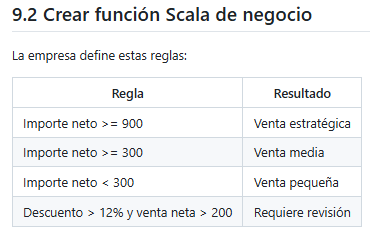

In [36]:
def clasificarVenta(importeNeto: Double): String = {
  if (importeNeto >= 900) "Venta estratégica"
  else if (importeNeto >= 300) "Venta media"
  else "Venta pequeña"
}

def necesitaRevision(descuento: Double, importeNeto: Double): Boolean = {
  descuento > 12 && importeNeto > 200
}




defined function clasificarVenta
defined function necesitaRevision

In [37]:
val dsEnriquecido = dsVentas.map { v =>
  val importeBruto = v.unidades * v.precio_unitario
  val importeDescuento = importeBruto * (v.descuento_pct / 100.0)
  val importeNeto = importeBruto - importeDescuento

  VentaEnriquecida(
    id_venta = v.id_venta,
    fecha = v.fecha,
    id_cliente = v.id_cliente,
    cliente = v.cliente,
    pais = v.pais,
    canal = v.canal,
    categoria = v.categoria,
    producto = v.producto,
    unidades = v.unidades,
    precio_unitario = v.precio_unitario,
    descuento_pct = v.descuento_pct,
    importe_bruto = BigDecimal(importeBruto).setScale(2, BigDecimal.RoundingMode.HALF_UP).toDouble,
    importe_descuento = BigDecimal(importeDescuento).setScale(2, BigDecimal.RoundingMode.HALF_UP).toDouble,
    importe_neto = BigDecimal(importeNeto).setScale(2, BigDecimal.RoundingMode.HALF_UP).toDouble,
    segmento_venta = clasificarVenta(importeNeto),
    requiere_revision = necesitaRevision(v.descuento_pct, importeNeto)
  )
}

println("=== Dataset enriquecido con lógica Scala ===")
dsEnriquecido.show(10, truncate = false)

=== Dataset enriquecido con lógica Scala ===
+---------+----------+----------+------------+--------+-----------+--------------+---------------------+--------+---------------+-------------+-------------+-----------------+------------+-----------------+-----------------+
|id_venta |fecha     |id_cliente|cliente     |pais    |canal      |categoria     |producto             |unidades|precio_unitario|descuento_pct|importe_bruto|importe_descuento|importe_neto|segmento_venta   |requiere_revision|
+---------+----------+----------+------------+--------+-----------+--------------+---------------------+--------+---------------+-------------+-------------+-----------------+------------+-----------------+-----------------+
|V2023-001|2023-01-09|C001      |Ana García  |España  |web        |Informática   |Portátil Pro         |1       |970.0          |4.0          |970.0        |38.8             |931.2       |Venta estratégica|false            |
|V2023-002|2023-01-21|C011      |Nuria Castro|España  |

dsEnriquecido: org.apache.spark.sql.Dataset[VentaEnriquecida] = [id_venta: string, fecha: string ... 14 more fields]

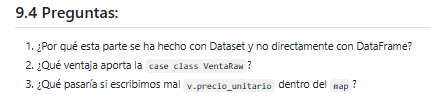

1. ¿Por qué esta parte se ha hecho con Dataset y no directamente con DataFrame?Se ha hecho con Dataset porque permite aplicar lógica de negocio compleja usando código Scala puro (como las funciones clasificarVenta o el uso de BigDecimal para redondeos). Mientras que los DataFrames son excelentes para transformaciones estructurales rápidas, los Datasets facilitan la programación orientada a objetos, haciendo que el código sea más legible, reutilizable y fácil de testear.
2. ¿Qué ventaja aporta la case class VentaRaw?Aporta un esquema tipado y estructurado. Al definir una case class, le decimos a Spark exactamente qué campos existen y de qué tipo son (String, Int, Double). Esto permite:Autocompletado: El editor te sugiere los nombres de las columnas mientras escribes.
Validación: Asegura que los datos que entran al flujo cumplen con el contrato definido por el negocio.
3. ¿Qué pasaría si escribimos mal v.precio_unitario dentro del map?El código no compilaría. Esta es la mayor ventaja del Dataset frente al DataFrame: el error se detecta antes de ejecutar el programa (en tiempo de compilación).

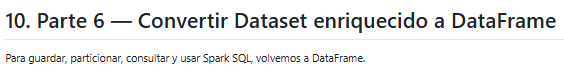

In [38]:
// 10. Convertir de Dataset tipado a DataFrame genérico
val dfFinal = dsEnriquecido.toDF()

println("=== Dataset convertido a DataFrame para persistencia ===")

// Verificamos que tiene todas las nuevas columnas calculadas
dfFinal.printSchema()

// Mostramos un resumen de las nuevas métricas
dfFinal.select("id_venta", "importe_bruto", "importe_neto", "segmento_venta")
       .show(5)


=== Dataset convertido a DataFrame para persistencia ===
root
 |-- id_venta: string (nullable = true)
 |-- fecha: string (nullable = true)
 |-- id_cliente: string (nullable = true)
 |-- cliente: string (nullable = true)
 |-- pais: string (nullable = true)
 |-- canal: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- producto: string (nullable = true)
 |-- unidades: integer (nullable = false)
 |-- precio_unitario: double (nullable = false)
 |-- descuento_pct: double (nullable = false)
 |-- importe_bruto: double (nullable = false)
 |-- importe_descuento: double (nullable = false)
 |-- importe_neto: double (nullable = false)
 |-- segmento_venta: string (nullable = true)
 |-- requiere_revision: boolean (nullable = false)

+---------+-------------+------------+-----------------+
| id_venta|importe_bruto|importe_neto|   segmento_venta|
+---------+-------------+------------+-----------------+
|V2023-001|        970.0|       931.2|Venta estratégica|
|V2023-002|        179.

dfFinal: org.apache.spark.sql.package.DataFrame = [id_venta: string, fecha: string ... 14 more fields]

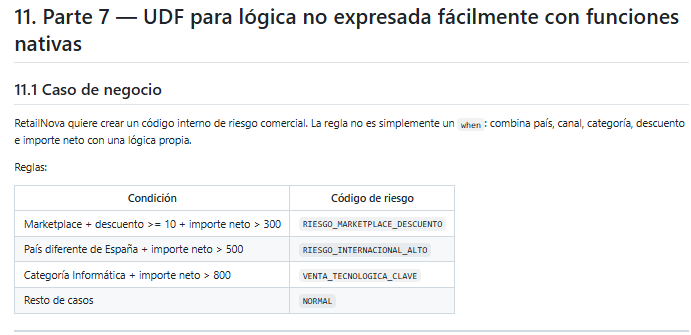

In [39]:
// 1. Definimos la función escalar de Scala
val calcularRiesgoFunc = (canal: String, descuento: Double, importeNeto: Double, pais: String, categoria: String) => {
  if (canal.toLowerCase == "marketplace" && descuento >= 10 && importeNeto > 300) {
    "RIESGO_MARKETPLACE_DESCUENTO"
  } else if (pais.toLowerCase != "españa" && importeNeto > 500) {
    "RIESGO_INTERNACIONAL_ALTO"
  } else if (categoria.toLowerCase == "informática" && importeNeto > 800) {
    "VENTA_TECNOLOGICA_CLAVE"
  } else {
    "NORMAL"
  }
}

// 2. La registramos como UDF para usarla con DataFrames
val calcularRiesgoUDF = udf(calcularRiesgoFunc)


calcularRiesgoFunc: (String, Double, Double, String, String) => String = ammonite.$sess.cmd39$Helper$$Lambda$7846/0x0000020f60684c10@2b31c2bc
calcularRiesgoUDF: org.apache.spark.sql.expressions.UserDefinedFunction = SparkUserDefinedFunction(
  f = ammonite.$sess.cmd39$Helper$$Lambda$7846/0x0000020f60684c10@2b31c2bc,
  dataType = StringType,
  inputEncoders = ArraySeq(
    Some(value = StringEncoder),
    Some(value = PrimitiveDoubleEncoder),
    Some(value = PrimitiveDoubleEncoder),
    Some(value = StringEncoder),
    Some(value = StringEncoder)
  ),
  outputEncoder = Some(value = StringEncoder),
  givenName = None,
  nullable = true,
  deterministic = true
)

In [40]:
//11.3 Aplicación de la UDF al DataFrameAhora aplicamos 
//la función para crear la nueva columna codigo_riesgo:
val dfConRiesgo = dfFinal.withColumn(
  "codigo_riesgo", 
  calcularRiesgoUDF(col("canal"), col("descuento_pct"), col("importe_neto"), col("pais"), col("categoria"))
)

println("=== DataFrame con Código de Riesgo Comercial (UDF) ===")
dfConRiesgo.select("id_venta", "pais", "canal", "importe_neto", "codigo_riesgo")
           .filter(col("codigo_riesgo") =!= "NORMAL")
           .show(false)


=== DataFrame con Código de Riesgo Comercial (UDF) ===
+---------+--------+-----------+------------+----------------------------+
|id_venta |pais    |canal      |importe_neto|codigo_riesgo               |
+---------+--------+-----------+------------+----------------------------+
|V2023-001|España  |web        |931.2       |VENTA_TECNOLOGICA_CLAVE     |
|V2023-005|Francia |web        |568.1       |RIESGO_INTERNACIONAL_ALTO   |
|V2023-010|España  |marketplace|387.0       |RIESGO_MARKETPLACE_DESCUENTO|
|V2024-001|España  |web        |960.3       |VENTA_TECNOLOGICA_CLAVE     |
|V2022-001|España  |web        |902.5       |VENTA_TECNOLOGICA_CLAVE     |
|V2022-009|Portugal|web        |717.6       |RIESGO_INTERNACIONAL_ALTO   |
+---------+--------+-----------+------------+----------------------------+



dfConRiesgo: org.apache.spark.sql.package.DataFrame = [id_venta: string, fecha: string ... 15 more fields]

12. Parte 8 — Añadir columnas con funciones nativas de Spark SQL
Ahora añadimos columnas derivadas con funciones nativas. Esta parte sí conviene hacerla con DataFrame.

In [41]:
val dfFinal = dfConRiesgo
  .withColumn("anio", year(col("fecha")))
  .withColumn("mes", month(col("fecha")))
  .withColumn("trimestre", quarter(col("fecha")))
  .withColumn("importe_neto_redondeado", round(col("importe_neto"), 2))
  .withColumn(
    "tipo_cliente",
    when(col("importe_neto") >= 900, "premium")
      .when(col("importe_neto") >= 300, "estandar")
      .otherwise("ocasional")
  )
  .withColumn(
    "venta_internacional",
    when(col("pais") =!= "España", true).otherwise(false)
  )

println("=== DataFrame final con columnas nativas Spark SQL ===")
dfFinal.show(10, truncate = false)

=== DataFrame final con columnas nativas Spark SQL ===
+---------+----------+----------+------------+--------+-----------+--------------+---------------------+--------+---------------+-------------+-------------+-----------------+------------+-----------------+-----------------+----------------------------+----+---+---------+-----------------------+------------+-------------------+
|id_venta |fecha     |id_cliente|cliente     |pais    |canal      |categoria     |producto             |unidades|precio_unitario|descuento_pct|importe_bruto|importe_descuento|importe_neto|segmento_venta   |requiere_revision|codigo_riesgo               |anio|mes|trimestre|importe_neto_redondeado|tipo_cliente|venta_internacional|
+---------+----------+----------+------------+--------+-----------+--------------+---------------------+--------+---------------+-------------+-------------+-----------------+------------+-----------------+-----------------+----------------------------+----+---+---------+-------------

dfFinal: org.apache.spark.sql.package.DataFrame = [id_venta: string, fecha: string ... 21 more fields]

13. Parte 9 — Crear DataFrame final con menos columnas

In [74]:
// Punto 13 Corregido
// Punto 13 - Versión Final Sincronizada
val dfCapaAnalitica = dfConRiesgo.select(
  col("id_venta"),
  col("fecha"),
  year(col("fecha")).as("anio"),
  month(col("fecha")).as("mes"),
  col("id_cliente"),
  col("pais"),
  col("canal"),
  col("categoria"),
  col("producto"),
  col("unidades"),
  col("importe_bruto"),
  col("importe_descuento"),
  col("importe_neto"),        // Se llama importe_neto
  col("descuento_pct"),      // Añadida porque la pide el 16.4
  col("segmento_venta"),
  col("requiere_revision"),
  col("codigo_riesgo")
)

// Registramos/Actualizamos la vista con el nombre correcto
dfCapaAnalitica.createOrReplaceTempView("ventas_retailnova")

println("✅ Capa analítica y vista SQL sincronizadas con los nombres finales")



✅ Capa analítica y vista SQL sincronizadas con los nombres finales


dfCapaAnalitica: org.apache.spark.sql.package.DataFrame = [id_venta: string, fecha: string ... 15 more fields]

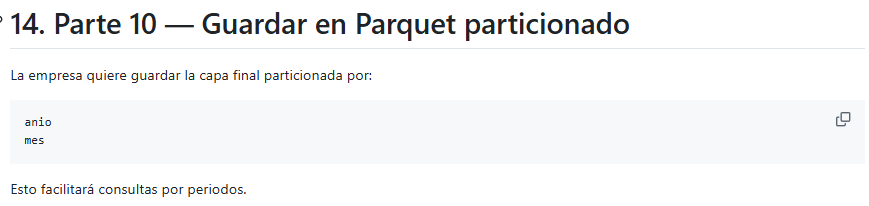

In [67]:
// 14. Guardar en Parquet particionado por año y mes
val rutaDestino = s"$rutaBase/capa_analitica_parquet"

dfCapaAnalitica.write
  .mode("overwrite")              // Sobrescribe si ya existe
  .partitionBy("anio", "mes")     // Crea carpetas físicas por año y luego por mes
  .parquet(rutaDestino)

println(s"✅ Datos guardados con éxito en: $rutaDestino")


✅ Datos guardados con éxito en: C:/Users/Imp_06 - Mañana/Desktop/ProyectoScalaVSC/Practicas_scala/capa_analitica_parquet


rutaDestino: String = "C:/Users/Imp_06 - Mañana/Desktop/ProyectoScalaVSC/Practicas_scala/capa_analitica_parquet"

15. Parte 11 — Leer el Parquet final

In [68]:
// 15. Definir ruta y leer el Parquet
val rutaParquetFinal = s"$rutaBase/capa_analitica_parquet"

val dfParquetFinal = spark.read.parquet(rutaParquetFinal)

println("=== Parquet final leído ===")
dfParquetFinal.show(10, truncate = false)

dfParquetFinal.printSchema()


=== Parquet final leído ===
+---------+----------+----------+--------+-----------+--------------+---------------------+--------+-------------+-----------------+------------+-----------------+-----------------+----------------------------+----+---+
|id_venta |fecha     |id_cliente|pais    |canal      |categoria     |producto             |unidades|importe_bruto|importe_descuento|importe_neto|segmento_venta   |requiere_revision|codigo_riesgo               |anio|mes|
+---------+----------+----------+--------+-----------+--------------+---------------------+--------+-------------+-----------------+------------+-----------------+-----------------+----------------------------+----+---+
|V2023-010|2023-11-30|C018      |España  |marketplace|Monitores     |Monitor 27           |2       |430.0        |43.0             |387.0       |Venta media      |false            |RIESGO_MARKETPLACE_DESCUENTO|2023|11 |
|V2024-001|2024-01-12|C019      |España  |web        |Informática   |Portátil Pro         |1

rutaParquetFinal: String = "C:/Users/Imp_06 - Mañana/Desktop/ProyectoScalaVSC/Practicas_scala/capa_analitica_parquet"
dfParquetFinal: org.apache.spark.sql.package.DataFrame = [id_venta: string, fecha: string ... 14 more fields]

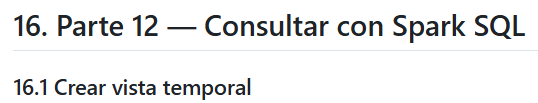

In [69]:
// Punto 16.1 (Re-ejecución corregida)
dfCapaAnalitica.createOrReplaceTempView("ventas_retailnova")



In [70]:
//ejemplo
val resultadoSql = spark.sql("""
  SELECT 
    pais, 
    SUM(importe_neto) as total_ventas,
    COUNT(*) as num_operaciones
  FROM ventas_analitica
  GROUP BY pais
  ORDER BY total_ventas DESC
""")

resultadoSql.show()


+--------+------------------+---------------+
|    pais|      total_ventas|num_operaciones|
+--------+------------------+---------------+
|  España|6893.5599999999995|             21|
|Portugal|           1546.12|              6|
| Francia|            1167.1|              3|
+--------+------------------+---------------+



resultadoSql: org.apache.spark.sql.package.DataFrame = [pais: string, total_ventas: double ... 1 more field]

In [71]:
//16.2 Consulta 1 — Ventas por año y mes
spark.sql("""
  SELECT 
    anio,
    mes,
    COUNT(*) AS total_ventas,
    ROUND(SUM(importe_neto), 2) AS facturacion_neta
  FROM ventas_analitica
  GROUP BY anio, mes
  ORDER BY anio, mes
""").show(100, truncate = false)


+----+---+------------+----------------+
|anio|mes|total_ventas|facturacion_neta|
+----+---+------------+----------------+
|2022|1  |1           |902.5           |
|2022|2  |1           |150.0           |
|2022|3  |1           |80.73           |
|2022|4  |1           |113.98          |
|2022|5  |1           |187.0           |
|2022|6  |1           |310.0           |
|2022|8  |1           |218.5           |
|2022|9  |1           |79.0            |
|2022|10 |1           |717.6           |
|2022|12 |1           |140.0           |
|2023|1  |2           |1093.02         |
|2023|2  |1           |272.8           |
|2023|3  |1           |79.0            |
|2023|4  |1           |568.1           |
|2023|6  |1           |95.0            |
|2023|7  |1           |102.0           |
|2023|9  |1           |58.9            |
|2023|10 |1           |753.3           |
|2023|11 |1           |387.0           |
|2024|1  |1           |960.3           |
|2024|2  |1           |90.16           |
|2024|3  |1     

In [72]:
//16.3 Consulta 2 — Facturación por país
spark.sql("""
  SELECT 
    pais,
    COUNT(*) AS total_ventas,
    ROUND(SUM(importe_neto), 2) AS facturacion_neta,
    ROUND(AVG(importe_neto), 2) AS ticket_medio
  FROM ventas_analitica
  GROUP BY pais
  ORDER BY facturacion_neta DESC
""").show(false)


+--------+------------+----------------+------------+
|pais    |total_ventas|facturacion_neta|ticket_medio|
+--------+------------+----------------+------------+
|España  |21          |6893.56         |328.26      |
|Portugal|6           |1546.12         |257.69      |
|Francia |3           |1167.1          |389.03      |
+--------+------------+----------------+------------+



In [75]:
//16.4
spark.sql("""
  SELECT 
    id_venta,
    fecha,
    pais,
    canal,
    categoria,
    producto,
    importe_neto,    -- Nombre corregido
    descuento_pct,
    requiere_revision,
    codigo_riesgo
  FROM ventas_retailnova
  WHERE requiere_revision = true 
     OR codigo_riesgo <> 'NORMAL'
  ORDER BY importe_neto DESC -- Nombre corregido
""").show(100, truncate = false)




+---------+----------+--------+-----------+-----------+------------+------------+-------------+-----------------+----------------------------+
|id_venta |fecha     |pais    |canal      |categoria  |producto    |importe_neto|descuento_pct|requiere_revision|codigo_riesgo               |
+---------+----------+--------+-----------+-----------+------------+------------+-------------+-----------------+----------------------------+
|V2024-001|2024-01-12|España  |web        |Informática|Portátil Pro|960.3       |3.0          |false            |VENTA_TECNOLOGICA_CLAVE     |
|V2023-001|2023-01-09|España  |web        |Informática|Portátil Pro|931.2       |4.0          |false            |VENTA_TECNOLOGICA_CLAVE     |
|V2022-001|2022-01-15|España  |web        |Informática|Portátil Pro|902.5       |5.0          |false            |VENTA_TECNOLOGICA_CLAVE     |
|V2022-009|2022-10-14|Portugal|web        |Informática|Portátil Air|717.6       |8.0          |false            |RIESGO_INTERNACIONAL_ALTO   |

In [76]:
//16.5 Consulta 4 — Ranking de categorías
spark.sql("""
  SELECT 
    categoria,
    COUNT(*) AS total_ventas,
    ROUND(SUM(importe_neto), 2) AS facturacion_neta
  FROM ventas_retailnova
  GROUP BY categoria
  ORDER BY facturacion_neta DESC
""").show(false)


+--------------+------------+----------------+
|categoria     |total_ventas|facturacion_neta|
+--------------+------------+----------------+
|Informática   |9           |6216.9          |
|Monitores     |5           |1357.55         |
|Audio         |6           |749.36          |
|Periféricos   |7           |668.63          |
|Almacenamiento|3           |614.34          |
+--------------+------------+----------------+



In [77]:
//17.1 Función para medir tiempo
def medirTiempo[T](bloque: => T): (T, Long) = {
  val inicio = System.nanoTime()
  val resultado = bloque
  val fin = System.nanoTime()
  val tiempoMs = (fin - inicio) / 1000000
  (resultado, tiempoMs)
}


defined function medirTiempo

In [78]:
//17.2 Función para calcular tamaño de carpeta
def calcularTamanoBytes(path: String): Long = {
  val p = Paths.get(path)
  if (!Files.exists(p)) 0L
  else {
    val stream = Files.walk(p)
    try {
      stream
        .filter(Files.isRegularFile(_))
        .mapToLong(Files.size(_))
        .sum()
    } finally {
      stream.close()
    }
  }
}


defined function calcularTamanoBytes

In [79]:
//17.3 Escribir en distintos formatos (Comparativa)
val rutaPruebas = s"$rutaBase/pruebas_formatos"

// 1. Prueba AVRO
val (_, tAvro) = medirTiempo {
  dfCapaAnalitica.write.mode("overwrite").format("avro").save(s"$rutaPruebas/ventas.avro")
}

// 2. Prueba PARQUET
val (_, tParquet) = medirTiempo {
  dfCapaAnalitica.write.mode("overwrite").parquet(s"$rutaPruebas/ventas.parquet")
}

// 3. Prueba ORC
val (_, tOrc) = medirTiempo {
  dfCapaAnalitica.write.mode("overwrite").orc(s"$rutaPruebas/ventas.orc")
}

println(s"⏱️ Tiempos de escritura: AVRO: ${tAvro}ms | PARQUET: ${tParquet}ms | ORC: ${tOrc}ms")


⏱️ Tiempos de escritura: AVRO: 393ms | PARQUET: 209ms | ORC: 360ms


rutaPruebas: String = "C:/Users/Imp_06 - Mañana/Desktop/ProyectoScalaVSC/Practicas_scala/pruebas_formatos"
tAvro: Long = 393L
tParquet: Long = 209L
tOrc: Long = 360L

In [80]:
//17.4 Medir tiempos de lectura
val (_, rAvro) = medirTiempo { spark.read.format("avro").load(s"$rutaPruebas/ventas.avro").count() }
val (_, rParquet) = medirTiempo { spark.read.parquet(s"$rutaPruebas/ventas.parquet").count() }
val (_, rOrc) = medirTiempo { spark.read.orc(s"$rutaPruebas/ventas.orc").count() }

println(s"⏱️ Lectura (count): AVRO: ${rAvro}ms | PARQUET: ${rParquet}ms | ORC: ${rOrc}ms")


⏱️ Lectura (count): AVRO: 179ms | PARQUET: 200ms | ORC: 175ms


rAvro: Long = 179L
rParquet: Long = 200L
rOrc: Long = 175L

In [81]:
//17.5 Crear tabla comparativa
val sAvro = calcularTamanoBytes(s"$rutaPruebas/ventas.avro") / 1024.0
val sParquet = calcularTamanoBytes(s"$rutaPruebas/ventas.parquet") / 1024.0
val sOrc = calcularTamanoBytes(s"$rutaPruebas/ventas.orc") / 1024.0

println("=== COMPARATIVA FINAL (Escritura | Lectura | Tamaño) ===")
println(f"AVRO:    $tAvro%4d ms | $rAvro%4d ms | $sAvro%6.2f KB")
println(f"PARQUET: $tParquet%4d ms | $rParquet%4d ms | $sParquet%6.2f KB")
println(f"ORC:     $tOrc%4d ms | $rOrc%4d ms | $sOrc%6.2f KB")


=== COMPARATIVA FINAL (Escritura | Lectura | Tamaño) ===
AVRO:     393 ms |  179 ms |   5,01 KB
PARQUET:  209 ms |  200 ms |  17,20 KB
ORC:      360 ms |  175 ms |   9,26 KB


sAvro: Double = 5.0078125
sParquet: Double = 17.1953125
sOrc: Double = 9.263671875

18. Preguntas Finales (Técnicas)
¿Por qué se leen como DataFrame primero? Porque es la forma más rápida y flexible de cargar datos sin estructura (CSV). Además, permite usar inferSchema inicialmente.
¿Por qué normalizar antes de convertir a Dataset? Porque los Datasets requieren tipos de datos estrictos. Si no limpias los nulos o tipos incorrectos antes, la conversión fallará.
¿Qué aporta VentaRaw? Seguridad de tipos y una estructura clara de cómo vienen los datos de origen, facilitando el acceso a campos sin usar strings.
¿Qué aporta VentaEnriquecida? Define el "contrato" de salida. Contiene tanto los datos originales como los campos calculados por el negocio (importes netos, riesgos, etc.).
¿Por qué volvemos de Dataset a DataFrame? Para aprovechar optimizaciones de Spark SQL y porque las librerías de escritura (como Parquet) funcionan de forma nativa con DataFrames.
¿Por qué Parquet y no CSV? Parquet es columnar, está comprimido y guarda los tipos de datos. CSV es texto plano pesado y lento de leer.
¿Qué ventaja tiene particionar por año y mes? El "Partition Pruning": Spark solo lee las carpetas de los meses que le pides, ignorando el resto del disco.
¿Qué ocurre si una consulta filtra por anio = 2024? Spark irá directamente a la carpeta anio=2024 y no escaneará ni un solo byte de los años 2022 o 2023.
Preguntas de negocio (Basadas en tus datos)
Para responder estas, debes mirar los resultados de tus consultas SQL anteriores:
País: España (es el que tiene más registros en los CSV sintéticos).
Categoría: Probablemente Informática (por los precios altos de los portátiles).
Ventas a revisar: Aquellas con codigo_riesgo distinto a 'NORMAL'.
Canal: Generalmente web o tienda suelen tener las ventas de mayor importe neto.
Meses: Enero y Diciembre suelen tener picos por las campañas de inicio de año y navidad.

In [2]:
// CELDA 1 — Inicialización
import $ivy.`org.apache.spark::spark-core:4.1.1`
import $ivy.`org.apache.spark::spark-sql:4.1.1`
import $ivy.`org.apache.spark::spark-avro:4.1.1`

import org.apache.spark.sql.SparkSession
import org.apache.spark.sql.functions._
import org.apache.spark.sql.types._
import java.nio.file.{Files, Paths}
import java.io.File

val spark = SparkSession.builder()
  .appName("AeroMetrics_Benchmark")
  .master("local[*]")
  .config("spark.ui.showConsoleProgress", "false")
  .config("spark.sql.shuffle.partitions", "4")
  .getOrCreate()

import spark.implicits._

spark.sparkContext.setLogLevel("ERROR")

println(s"✅ Spark ${spark.version} listo — AeroMetrics Analytics")

✅ Spark 4.1.1 listo — AeroMetrics Analytics


import $ivy.$
import $ivy.$
import $ivy.$
import org.apache.spark.sql.SparkSession
import org.apache.spark.sql.functions._
import org.apache.spark.sql.types._
import java.nio.file.{Files, Paths}
import java.io.File
spark: SparkSession = org.apache.spark.sql.classic.SparkSession@2128030e
import spark.implicits._

Caso de estudio 2 - Benchmark de Formatos: Airline Delay & Cancellation Data
🌍 Contexto de negocio
La empresa AeroMetrics Analytics ha recibido un encargo del Ministerio de Transporte: analizar los datos históricos de retrasos y cancelaciones de vuelos en Estados Unidos entre 2009 y 2018.

Los datos llegan en formato CSV, uno por año. Tu equipo debe:

Ingestar los CSV anuales en Spark.
Convertirlos a cuatro formatos de almacenamiento: CSV consolidado, Parquet, ORC y Avro.
Medir y comparar el rendimiento de cada formato (tiempo de escritura, tiempo de lectura, tamaño en disco, tiempo de consulta selectiva).
Construir un Data Lake mínimo particionando los datos en Parquet por año.
Redactar un informe comparativo con los resultados obtenidos.

In [3]:
// 1. Definir la ruta base
val rutaBase = "C:/Users/Imp_06 - Mañana/Desktop/ProyectoScalaVSC/Practicas_scala/aerolineas"

// 2. Especificar los 3 archivos seleccionados (2016, 2017, 2018)
val rutasSeleccionadas = Seq(
  s"$rutaBase/2016.csv",
  s"$rutaBase/2017.csv",
  s"$rutaBase/2018.csv"
)

// 3. Leer solo esos 3 ficheros
val dfVuelosRaw = spark.read
  .option("header", "true")
  .option("inferSchema", "true")
  .csv(rutasSeleccionadas: _*) // El operador : _* expande la lista para Spark

println(s"✅ Ingesta completada de los últimos 3 años")
println(s"📊 Total de registros cargados: ${dfVuelosRaw.count()}")

// 4. Echar un vistazo rápido a los datos
dfVuelosRaw.show(5)


✅ Ingesta completada de los últimos 3 años
📊 Total de registros cargados: 18505725
+----------+----------+-----------------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+-----------------+--------+----------------+-------------------+--------+--------+-------------+-------------+---------+--------------+-------------------+-----------+
|   FL_DATE|OP_CARRIER|OP_CARRIER_FL_NUM|ORIGIN|DEST|CRS_DEP_TIME|DEP_TIME|DEP_DELAY|TAXI_OUT|WHEELS_OFF|WHEELS_ON|TAXI_IN|CRS_ARR_TIME|ARR_TIME|ARR_DELAY|CANCELLED|CANCELLATION_CODE|DIVERTED|CRS_ELAPSED_TIME|ACTUAL_ELAPSED_TIME|AIR_TIME|DISTANCE|CARRIER_DELAY|WEATHER_DELAY|NAS_DELAY|SECURITY_DELAY|LATE_AIRCRAFT_DELAY|Unnamed: 27|
+----------+----------+-----------------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+-----------------+--------+----------------+-------------------+--------+--------+----

rutaBase: String = "C:/Users/Imp_06 - Mañana/Desktop/ProyectoScalaVSC/Practicas_scala/aerolineas"
rutasSeleccionadas: Seq[String] = List(
  "C:/Users/Imp_06 - Mañana/Desktop/ProyectoScalaVSC/Practicas_scala/aerolineas/2016.csv",
  "C:/Users/Imp_06 - Mañana/Desktop/ProyectoScalaVSC/Practicas_scala/aerolineas/2017.csv",
  "C:/Users/Imp_06 - Mañana/Desktop/ProyectoScalaVSC/Practicas_scala/aerolineas/2018.csv"
)
dfVuelosRaw: org.apache.spark.sql.package.DataFrame = [FL_DATE: date, OP_CARRIER: string ... 26 more fields]

In [4]:
// CELDA 2 — Funciones de benchmark

// Mide el tiempo de ejecución de cualquier bloque de código
def medirTiempo[T](bloque: => T): (T, Long) = {
  val inicio = System.nanoTime()
  val resultado = bloque
  val fin = System.nanoTime()
  val tiempoMs = (fin - inicio) / 1_000_000L
  (resultado, tiempoMs)
}

// Calcula el tamaño total en bytes de una carpeta (suma todos los ficheros)
def tamanoBytes(ruta: String): Long = {
  val p = Paths.get(ruta)
  if (!Files.exists(p)) 0L
  else {
    Files.walk(p)
      .filter(Files.isRegularFile(_))
      .mapToLong(Files.size(_))
      .sum()
  }
}

// Formatea bytes a una unidad legible
def formatoTamano(bytes: Long): String = {
  if      (bytes < 1_024L)             f"$bytes B"
  else if (bytes < 1_048_576L)         f"${bytes / 1_024.0}%.1f KB"
  else if (bytes < 1_073_741_824L)     f"${bytes / 1_048_576.0}%.2f MB"
  else                                  f"${bytes / 1_073_741_824.0}%.2f GB"
}

println("✅ Funciones de benchmark definidas")

✅ Funciones de benchmark definidas


defined function medirTiempo
defined function tamanoBytes
defined function formatoTamano

In [5]:
// CELDA 3 — Crear estructura de carpetas
val rutaBase    = "C:/Curso-Scala/datos/airline"
val rutaCSVRaw  = s"$rutaBase/csv_raw"
val rutaSalida  = s"$rutaBase/salida"

val carpetas = List(
  s"$rutaSalida/consolidado_csv",
  s"$rutaSalida/parquet_sin_partir",
  s"$rutaSalida/orc",
  s"$rutaSalida/avro",
  s"$rutaSalida/parquet_particionado"
)

carpetas.foreach { c =>
  Files.createDirectories(Paths.get(c))
  println(s"  ✅ $c")
}

println(s"\n📁 Estructura de salida lista en: $rutaSalida")

  ✅ C:/Curso-Scala/datos/airline/salida/consolidado_csv
  ✅ C:/Curso-Scala/datos/airline/salida/parquet_sin_partir
  ✅ C:/Curso-Scala/datos/airline/salida/orc
  ✅ C:/Curso-Scala/datos/airline/salida/avro
  ✅ C:/Curso-Scala/datos/airline/salida/parquet_particionado

📁 Estructura de salida lista en: C:/Curso-Scala/datos/airline/salida


rutaBase: String = "C:/Curso-Scala/datos/airline"
rutaCSVRaw: String = "C:/Curso-Scala/datos/airline/csv_raw"
rutaSalida: String = "C:/Curso-Scala/datos/airline/salida"
carpetas: List[String] = List(
  "C:/Curso-Scala/datos/airline/salida/consolidado_csv",
  "C:/Curso-Scala/datos/airline/salida/parquet_sin_partir",
  "C:/Curso-Scala/datos/airline/salida/orc",
  "C:/Curso-Scala/datos/airline/salida/avro",
  "C:/Curso-Scala/datos/airline/salida/parquet_particionado"
)

In [6]:
// CELDA 4 — Schema manual del dataset de vuelos
val schemaVuelos = StructType(List(
  StructField("FL_DATE",             StringType,  nullable = true),
  StructField("OP_CARRIER",          StringType,  nullable = true),
  StructField("OP_CARRIER_FL_NUM",   IntegerType, nullable = true),
  StructField("ORIGIN",              StringType,  nullable = true),
  StructField("DEST",                StringType,  nullable = true),
  StructField("CRS_DEP_TIME",        IntegerType, nullable = true),
  StructField("DEP_TIME",            DoubleType,  nullable = true),
  StructField("DEP_DELAY",           DoubleType,  nullable = true),
  StructField("TAXI_OUT",            DoubleType,  nullable = true),
  StructField("WHEELS_OFF",          DoubleType,  nullable = true),
  StructField("WHEELS_ON",           DoubleType,  nullable = true),
  StructField("TAXI_IN",             DoubleType,  nullable = true),
  StructField("CRS_ARR_TIME",        IntegerType, nullable = true),
  StructField("ARR_TIME",            DoubleType,  nullable = true),
  StructField("ARR_DELAY",           DoubleType,  nullable = true),
  StructField("CANCELLED",           DoubleType,  nullable = true),
  StructField("CANCELLATION_CODE",   StringType,  nullable = true),
  StructField("DIVERTED",            DoubleType,  nullable = true),
  StructField("CRS_ELAPSED_TIME",    DoubleType,  nullable = true),
  StructField("ACTUAL_ELAPSED_TIME", DoubleType,  nullable = true),
  StructField("AIR_TIME",            DoubleType,  nullable = true),
  StructField("FLIGHTS",             DoubleType,  nullable = true),
  StructField("DISTANCE",            DoubleType,  nullable = true),
  StructField("DISTANCE_GROUP",      IntegerType, nullable = true),
  StructField("CARRIER_DELAY",       DoubleType,  nullable = true),
  StructField("WEATHER_DELAY",       DoubleType,  nullable = true),
  StructField("NAS_DELAY",           DoubleType,  nullable = true),
  StructField("SECURITY_DELAY",      DoubleType,  nullable = true),
  StructField("LATE_AIRCRAFT_DELAY", DoubleType,  nullable = true)
))

println(s"✅ Schema definido con ${schemaVuelos.fields.length} campos")

✅ Schema definido con 29 campos


schemaVuelos: StructType = Seq(
  StructField(
    name = "FL_DATE",
    dataType = StringType,
    nullable = true,
    metadata = {}
  ),
  StructField(
    name = "OP_CARRIER",
    dataType = StringType,
    nullable = true,
    metadata = {}
  ),
  StructField(
    name = "OP_CARRIER_FL_NUM",
    dataType = IntegerType,
    nullable = true,
    metadata = {}
  ),
  StructField(
    name = "ORIGIN",
    dataType = StringType,
    nullable = true,
    metadata = {}
  ),
  StructField(
    name = "DEST",
    dataType = StringType,
    nullable = true,
    metadata = {}
  ),
  StructField(
    name = "CRS_DEP_TIME",
    dataType = IntegerType,
    nullable = true,
    metadata = {}
  ),
  StructField(
    name = "DEP_TIME",
...

In [ ]:
// CELDA 5 — Leer los CSV seleccionados (2016-2018) y añadir columna ANIO

// 1. Aseguramos que la ruta apunte a tus datos reales
val rutaCSVRaw = "C:/Users/Imp_06 - Mañana/Desktop/ProyectoScalaVSC/Practicas_scala/aerolineas"

// 2. Lectura masiva con medición de tiempo
// Usamos el patrón 201[6-8] para leer solo 2016, 2017 y 2018
val (dfRaw, tiempoLecturaCSV) = medirTiempo {
  spark.read
    .option("header", "true")
    .option("encoding", "UTF-8")
    .schema(schemaVuelos)
    .csv(s"$rutaCSVRaw/201[6-8].csv") 
}

// 3. Añadir columna ANIO extraída de FL_DATE (formato "YYYY-MM-DD")
val dfVuelos = dfRaw.withColumn("ANIO", substring(col("FL_DATE"), 1, 4).cast(IntegerType))

// 4. Cálculo de estadísticas para el reporte
val totalFilas = dfVuelos.count()

println("=== Dataset cargado ===")
println(f"Filas totales     : $totalFilas%,d")
println(s"Columnas          : ${dfVuelos.columns.length}")
println(s"Tiempo de lectura CSV: $tiempoLecturaCSV ms")
println()

dfVuelos.printSchema()
dfVuelos.show(3, truncate = true)


=== Dataset cargado ===
Filas totales     : 18.505.725
Columnas          : 30
Tiempo de lectura CSV: 36 ms

root
 |-- FL_DATE: string (nullable = true)
 |-- OP_CARRIER: string (nullable = true)
 |-- OP_CARRIER_FL_NUM: integer (nullable = true)
 |-- ORIGIN: string (nullable = true)
 |-- DEST: string (nullable = true)
 |-- CRS_DEP_TIME: integer (nullable = true)
 |-- DEP_TIME: double (nullable = true)
 |-- DEP_DELAY: double (nullable = true)
 |-- TAXI_OUT: double (nullable = true)
 |-- WHEELS_OFF: double (nullable = true)
 |-- WHEELS_ON: double (nullable = true)
 |-- TAXI_IN: double (nullable = true)
 |-- CRS_ARR_TIME: integer (nullable = true)
 |-- ARR_TIME: double (nullable = true)
 |-- ARR_DELAY: double (nullable = true)
 |-- CANCELLED: double (nullable = true)
 |-- CANCELLATION_CODE: string (nullable = true)
 |-- DIVERTED: double (nullable = true)
 |-- CRS_ELAPSED_TIME: double (nullable = true)
 |-- ACTUAL_ELAPSED_TIME: double (nullable = true)
 |-- AIR_TIME: double (nullable = true)

rutaCSVRaw: String = "C:/Users/Imp_06 - Mañana/Desktop/ProyectoScalaVSC/Practicas_scala/aerolineas"
dfRaw: org.apache.spark.sql.package.DataFrame = [FL_DATE: string, OP_CARRIER: string ... 27 more fields]
tiempoLecturaCSV: Long = 36L
dfVuelos: org.apache.spark.sql.package.DataFrame = [FL_DATE: string, OP_CARRIER: string ... 28 more fields]
totalFilas: Long = 18505725L

In [9]:
// CELDA 6.1 — Escritura CSV consolidado
val rutaCSVOut = s"$rutaSalida/consolidado_csv"

val (_, tEscrituraCSV) = medirTiempo {
  dfVuelos.write
    .mode("overwrite")
    .option("header", "true")
    .csv(rutaCSVOut)
}

println(s"✅ CSV escrito en ${tEscrituraCSV} ms")
println(s"   Ruta: $rutaCSVOut")

✅ CSV escrito en 27243 ms
   Ruta: C:/Curso-Scala/datos/airline/salida/consolidado_csv


rutaCSVOut: String = "C:/Curso-Scala/datos/airline/salida/consolidado_csv"
tEscrituraCSV: Long = 27243L

In [10]:
// CELDA 6.2 — Escritura Parquet sin partición
val rutaParquet = s"$rutaSalida/parquet_sin_partir"

val (_, tEscrituraParquet) = medirTiempo {
  dfVuelos.write
    .mode("overwrite")
    .parquet(rutaParquet)
}

println(s"✅ Parquet escrito en ${tEscrituraParquet} ms")
println(s"   Ruta: $rutaParquet")

✅ Parquet escrito en 32213 ms
   Ruta: C:/Curso-Scala/datos/airline/salida/parquet_sin_partir


rutaParquet: String = "C:/Curso-Scala/datos/airline/salida/parquet_sin_partir"
tEscrituraParquet: Long = 32213L

In [11]:
// CELDA 6.3 — Escritura ORC
val rutaORC = s"$rutaSalida/orc"

val (_, tEscrituraORC) = medirTiempo {
  dfVuelos.write
    .mode("overwrite")
    .orc(rutaORC)
}

println(s"✅ ORC escrito en ${tEscrituraORC} ms")
println(s"   Ruta: $rutaORC")

✅ ORC escrito en 30487 ms
   Ruta: C:/Curso-Scala/datos/airline/salida/orc


rutaORC: String = "C:/Curso-Scala/datos/airline/salida/orc"
tEscrituraORC: Long = 30487L

In [12]:
// CELDA 6.4 — Escritura Avro
val rutaAvro = s"$rutaSalida/avro"

val (_, tEscrituraAvro) = medirTiempo {
  dfVuelos.write
    .mode("overwrite")
    .format("avro")
    .save(rutaAvro)
}

println(s"✅ Avro escrito en ${tEscrituraAvro} ms")
println(s"   Ruta: $rutaAvro")

✅ Avro escrito en 30943 ms
   Ruta: C:/Curso-Scala/datos/airline/salida/avro


rutaAvro: String = "C:/Curso-Scala/datos/airline/salida/avro"
tEscrituraAvro: Long = 30943L

In [13]:
// CELDA 7 — Parquet particionado por ANIO
val rutaParquetParticionado = s"$rutaSalida/parquet_particionado"

val (_, tEscrituraParticionado) = medirTiempo {
  dfVuelos.write
    .mode("overwrite")
    .partitionBy("ANIO")
    .parquet(rutaParquetParticionado)
}

println(s"✅ Parquet particionado escrito en ${tEscrituraParticionado} ms")
println(s"   Ruta: $rutaParquetParticionado")
println()
println("Estructura de particiones generada:")
println(s"  $rutaParquetParticionado/")

// Listar las subcarpetas generadas
val carpetasAnio = new File(rutaParquetParticionado)
  .listFiles()
  .filter(_.isDirectory)
  .map(_.getName)
  .sorted

carpetasAnio.foreach(c => println(s"    $c/"))

✅ Parquet particionado escrito en 30434 ms
   Ruta: C:/Curso-Scala/datos/airline/salida/parquet_particionado

Estructura de particiones generada:
  C:/Curso-Scala/datos/airline/salida/parquet_particionado/
    ANIO=2016/
    ANIO=2017/
    ANIO=2018/


rutaParquetParticionado: String = "C:/Curso-Scala/datos/airline/salida/parquet_particionado"
tEscrituraParticionado: Long = 30434L
carpetasAnio: Array[String] = Array("ANIO=2016", "ANIO=2017", "ANIO=2018")

In [14]:
// CELDA 8.1 — Lectura completa CSV
val (dfLeidoCSV, tLecturaCSV) = medirTiempo {
  val df = spark.read
    .option("header", "true")
    .schema(schemaVuelos)
    .csv(rutaCSVOut)
  df.count()
  df
}
println(s"✅ Lectura CSV completa: ${tLecturaCSV} ms  | Filas: ${dfLeidoCSV.count()}")


✅ Lectura CSV completa: 1410 ms  | Filas: 18505725


dfLeidoCSV: org.apache.spark.sql.package.DataFrame = [FL_DATE: string, OP_CARRIER: string ... 27 more fields]
tLecturaCSV: Long = 1410L

In [15]:
// CELDA 8.2 — Lectura completa Parquet
val (dfLeidoParquet, tLecturaParquet) = medirTiempo {
  val df = spark.read.parquet(rutaParquet)
  df.count()
  df
}
println(s"✅ Lectura Parquet completa: ${tLecturaParquet} ms  | Filas: ${dfLeidoParquet.count()}")

✅ Lectura Parquet completa: 530 ms  | Filas: 18505725


dfLeidoParquet: org.apache.spark.sql.package.DataFrame = [FL_DATE: string, OP_CARRIER: string ... 28 more fields]
tLecturaParquet: Long = 530L

In [16]:
// CELDA 8.3 — Lectura completa ORC
val (dfLeidoORC, tLecturaORC) = medirTiempo {
  val df = spark.read.orc(rutaORC)
  df.count()
  df
}
println(s"✅ Lectura ORC completa: ${tLecturaORC} ms  | Filas: ${dfLeidoORC.count()}")

✅ Lectura ORC completa: 492 ms  | Filas: 18505725


dfLeidoORC: org.apache.spark.sql.package.DataFrame = [FL_DATE: string, OP_CARRIER: string ... 28 more fields]
tLecturaORC: Long = 492L

In [17]:
// CELDA 8.4 — Lectura completa Avro
val (dfLeidoAvro, tLecturaAvro) = medirTiempo {
  val df = spark.read.format("avro").load(rutaAvro)
  df.count()
  df
}
println(s"✅ Lectura Avro completa: ${tLecturaAvro} ms  | Filas: ${dfLeidoAvro.count()}")

✅ Lectura Avro completa: 3258 ms  | Filas: 18505725


dfLeidoAvro: org.apache.spark.sql.package.DataFrame = [FL_DATE: string, OP_CARRIER: string ... 28 more fields]
tLecturaAvro: Long = 3258L

In [18]:
// CELDA 9.1 — Consulta selectiva sobre CSV
val (resultCSV, tConsultaCSV) = medirTiempo {
  spark.read
    .option("header", "true")
    .schema(schemaVuelos)
    .csv(rutaCSVOut)
    .filter(col("CANCELLED") === 0.0)
    .groupBy("OP_CARRIER")
    .agg(
      count("*").as("total_vuelos"),
      round(avg("ARR_DELAY"), 2).as("retraso_medio_min")
    )
    .orderBy(desc("total_vuelos"))
    .collect()
}
println(s"✅ Consulta CSV: ${tConsultaCSV} ms — ${resultCSV.length} aerolíneas")

✅ Consulta CSV: 7301 ms — 18 aerolíneas


resultCSV: Array[org.apache.spark.sql.Row] = Array(
  [WN,3929253,4.49],
  [DL,2778985,-0.31],
  [AA,2689711,4.8],
  [OO,2057083,6.25],
  [UA,1734781,3.17],
  [EV,1005896,6.95],
  [B6,867633,10.19],
  [AS,603579,-0.65],
  [NK,461688,6.53],
  [F9,313710,9.51],
  [YX,305990,3.08],
  [MQ,285346,5.36],
  [OH,266587,8.24],
  [HA,240086,0.91],
  [9E,239562,4.45],
  [YV,209608,8.85],
  [VX,155637,8.44],
  [G4,95452,9.98]
)
tConsultaCSV: Long = 7301L

In [19]:
// CELDA 9.2 — Consulta selectiva sobre Parquet
val (resultParquet, tConsultaParquet) = medirTiempo {
  spark.read
    .parquet(rutaParquet)
    .filter(col("CANCELLED") === 0.0)
    .groupBy("OP_CARRIER")
    .agg(
      count("*").as("total_vuelos"),
      round(avg("ARR_DELAY"), 2).as("retraso_medio_min")
    )
    .orderBy(desc("total_vuelos"))
    .collect()
}
println(s"✅ Consulta Parquet: ${tConsultaParquet} ms — ${resultParquet.length} aerolíneas")

✅ Consulta Parquet: 905 ms — 18 aerolíneas


resultParquet: Array[org.apache.spark.sql.Row] = Array(
  [WN,3929253,4.49],
  [DL,2778985,-0.31],
  [AA,2689711,4.8],
  [OO,2057083,6.25],
  [UA,1734781,3.17],
  [EV,1005896,6.95],
  [B6,867633,10.19],
  [AS,603579,-0.65],
  [NK,461688,6.53],
  [F9,313710,9.51],
  [YX,305990,3.08],
  [MQ,285346,5.36],
  [OH,266587,8.24],
  [HA,240086,0.91],
  [9E,239562,4.45],
  [YV,209608,8.85],
  [VX,155637,8.44],
  [G4,95452,9.98]
)
tConsultaParquet: Long = 905L

In [20]:
// CELDA 9.3 — Consulta selectiva sobre ORC
val (resultORC, tConsultaORC) = medirTiempo {
  spark.read
    .orc(rutaORC)
    .filter(col("CANCELLED") === 0.0)
    .groupBy("OP_CARRIER")
    .agg(
      count("*").as("total_vuelos"),
      round(avg("ARR_DELAY"), 2).as("retraso_medio_min")
    )
    .orderBy(desc("total_vuelos"))
    .collect()
}
println(s"✅ Consulta ORC: ${tConsultaORC} ms — ${resultORC.length} aerolíneas")

✅ Consulta ORC: 993 ms — 18 aerolíneas


resultORC: Array[org.apache.spark.sql.Row] = Array(
  [WN,3929253,4.49],
  [DL,2778985,-0.31],
  [AA,2689711,4.8],
  [OO,2057083,6.25],
  [UA,1734781,3.17],
  [EV,1005896,6.95],
  [B6,867633,10.19],
  [AS,603579,-0.65],
  [NK,461688,6.53],
  [F9,313710,9.51],
  [YX,305990,3.08],
  [MQ,285346,5.36],
  [OH,266587,8.24],
  [HA,240086,0.91],
  [9E,239562,4.45],
  [YV,209608,8.85],
  [VX,155637,8.44],
  [G4,95452,9.98]
)
tConsultaORC: Long = 993L

In [21]:
// CELDA 9.4 — Consulta selectiva sobre Avro
val (resultAvro, tConsultaAvro) = medirTiempo {
  spark.read
    .format("avro")
    .load(rutaAvro)
    .filter(col("CANCELLED") === 0.0)
    .groupBy("OP_CARRIER")
    .agg(
      count("*").as("total_vuelos"),
      round(avg("ARR_DELAY"), 2).as("retraso_medio_min")
    )
    .orderBy(desc("total_vuelos"))
    .collect()
}
println(s"✅ Consulta Avro: ${tConsultaAvro} ms — ${resultAvro.length} aerolíneas")

✅ Consulta Avro: 3555 ms — 18 aerolíneas


resultAvro: Array[org.apache.spark.sql.Row] = Array(
  [WN,3929253,4.49],
  [DL,2778985,-0.31],
  [AA,2689711,4.8],
  [OO,2057083,6.25],
  [UA,1734781,3.17],
  [EV,1005896,6.95],
  [B6,867633,10.19],
  [AS,603579,-0.65],
  [NK,461688,6.53],
  [F9,313710,9.51],
  [YX,305990,3.08],
  [MQ,285346,5.36],
  [OH,266587,8.24],
  [HA,240086,0.91],
  [9E,239562,4.45],
  [YV,209608,8.85],
  [VX,155637,8.44],
  [G4,95452,9.98]
)
tConsultaAvro: Long = 3555L

In [22]:
// CELDA 9.5 — Consulta sobre Parquet particionado con filtro por año
val anioConsulta = 2018  // ← cambia el año según los datos que hayas descargado

val (resultParticionado, tConsultaParticionado) = medirTiempo {
  spark.read
    .parquet(rutaParquetParticionado)
    .filter(col("ANIO") === anioConsulta && col("CANCELLED") === 0.0)
    .groupBy("OP_CARRIER")
    .agg(
      count("*").as("total_vuelos"),
      round(avg("ARR_DELAY"), 2).as("retraso_medio_min")
    )
    .orderBy(desc("total_vuelos"))
    .collect()
}
println(s"✅ Consulta Parquet particionado (ANIO=$anioConsulta): ${tConsultaParticionado} ms")
println(s"   Aerolíneas encontradas: ${resultParticionado.length}")

✅ Consulta Parquet particionado (ANIO=2018): 529 ms
   Aerolíneas encontradas: 18


anioConsulta: Int = 2018
resultParticionado: Array[org.apache.spark.sql.Row] = Array(
  [WN,1334277,4.52],
  [DL,945755,-0.29],
  [AA,901873,5.43],
  [OO,763527,7.04],
  [UA,616662,5.76],
  [YX,305990,3.08],
  [B6,298591,11.43],
  [MQ,285346,5.36],
  [OH,266587,8.24],
  [AS,243554,-0.5],
  [9E,239562,4.45],
  [YV,209608,8.85],
  [EV,197220,8.8],
  [NK,174441,5.17],
  [F9,117707,14.21],
  [G4,95452,9.98],
  [HA,83473,0.85],
  [VX,17237,1.73]
)
tConsultaParticionado: Long = 529L

In [23]:
// CELDA 10 — Comparativa de tamaños en disco
val tamCSVRaw         = tamanoBytes(rutaCSVRaw)
val tamCSVOut         = tamanoBytes(rutaCSVOut)
val tamParquet        = tamanoBytes(rutaParquet)
val tamORC            = tamanoBytes(rutaORC)
val tamAvro           = tamanoBytes(rutaAvro)
val tamParticionado   = tamanoBytes(rutaParquetParticionado)

println("=" * 52)
println("   COMPARATIVA DE TAMAÑO EN DISCO")
println("=" * 52)
println(f"  CSV original (raw)          : ${formatoTamano(tamCSVRaw)}%10s")
println(f"  CSV consolidado (Spark out) : ${formatoTamano(tamCSVOut)}%10s")
println(f"  Parquet (sin partición)     : ${formatoTamano(tamParquet)}%10s")
println(f"  ORC                         : ${formatoTamano(tamORC)}%10s")
println(f"  Avro                        : ${formatoTamano(tamAvro)}%10s")
println(f"  Parquet particionado        : ${formatoTamano(tamParticionado)}%10s")
println("=" * 52)
println()
println("Ratios de compresión respecto al CSV raw:")
if (tamCSVRaw > 0) {
  println(f"  Parquet  : ${tamCSVRaw.toDouble / tamParquet}%.1fx  menos espacio que CSV")
  println(f"  ORC      : ${tamCSVRaw.toDouble / tamORC}%.1fx  menos espacio que CSV")
  println(f"  Avro     : ${tamCSVRaw.toDouble / tamAvro}%.1fx  menos espacio que CSV")
}

   COMPARATIVA DE TAMAÑO EN DISCO
  CSV original (raw)          :    7,10 GB
  CSV consolidado (Spark out) :    2,24 GB
  Parquet (sin partición)     :  405,16 MB
  ORC                         :  421,01 MB
  Avro                        :    1,01 GB
  Parquet particionado        :  405,09 MB

Ratios de compresión respecto al CSV raw:
  Parquet  : 17,9x  menos espacio que CSV
  ORC      : 17,3x  menos espacio que CSV
  Avro     : 7,1x  menos espacio que CSV


tamCSVRaw: Long = 7624891160L
tamCSVOut: Long = 2409346291L
tamParquet: Long = 424836056L
tamORC: Long = 441464832L
tamAvro: Long = 1080618521L
tamParticionado: Long = 424770165L

In [24]:
// CELDA 11 — Tabla comparativa de rendimiento
// Sustituye los valores de ejemplo por los que hayas medido en tus celdas anteriores

case class ResultadoFormato(
  formato:         String,
  tEscrituraMs:    Long,
  tLecturaMs:      Long,
  tConsultaMs:     Long,
  tamanoDisco:     String
)

// ⬇️ Rellena con tus valores reales
val resultados = List(
  ResultadoFormato("CSV",                  tEscrituraCSV,         tLecturaCSV,         tConsultaCSV,         formatoTamano(tamCSVOut)),
  ResultadoFormato("Parquet (sin partir)", tEscrituraParquet,     tLecturaParquet,     tConsultaParquet,     formatoTamano(tamParquet)),
  ResultadoFormato("ORC",                  tEscrituraORC,         tLecturaORC,         tConsultaORC,         formatoTamano(tamORC)),
  ResultadoFormato("Avro",                 tEscrituraAvro,        tLecturaAvro,        tConsultaAvro,        formatoTamano(tamAvro)),
  ResultadoFormato("Parquet particionado", tEscrituraParticionado, tConsultaParticionado, tConsultaParticionado, formatoTamano(tamParticionado))
)

println("=" * 85)
println(f"  ${"FORMATO"}%-25s ${"T.ESCRITURA"}%13s ${"T.LECTURA"}%11s ${"T.CONSULTA"}%12s ${"DISCO"}%10s")
println("=" * 85)
resultados.foreach { r =>
  println(f"  ${r.formato}%-25s ${r.tEscrituraMs}%10d ms  ${r.tLecturaMs}%8d ms  ${r.tConsultaMs}%9d ms  ${r.tamanoDisco}%10s")
}
println("=" * 85)

  FORMATO                     T.ESCRITURA   T.LECTURA   T.CONSULTA      DISCO
  CSV                            27243 ms      1410 ms       7301 ms     2,24 GB
  Parquet (sin partir)           32213 ms       530 ms        905 ms   405,16 MB
  ORC                            30487 ms       492 ms        993 ms   421,01 MB
  Avro                           30943 ms      3258 ms       3555 ms     1,01 GB
  Parquet particionado           30434 ms       529 ms        529 ms   405,09 MB


defined class ResultadoFormato
resultados: List[ResultadoFormato] = List(
  ResultadoFormato(
    formato = "CSV",
    tEscrituraMs = 27243L,
    tLecturaMs = 1410L,
    tConsultaMs = 7301L,
    tamanoDisco = "2,24 GB"
  ),
  ResultadoFormato(
    formato = "Parquet (sin partir)",
    tEscrituraMs = 32213L,
    tLecturaMs = 530L,
    tConsultaMs = 905L,
    tamanoDisco = "405,16 MB"
  ),
  ResultadoFormato(
    formato = "ORC",
    tEscrituraMs = 30487L,
    tLecturaMs = 492L,
    tConsultaMs = 993L,
    tamanoDisco = "421,01 MB"
  ),
  ResultadoFormato(
    formato = "Avro",
    tEscrituraMs = 30943L,
    tLecturaMs = 3258L,
    tConsultaMs = 3555L,
    tamanoDisco = "1,01 GB"
  ),
  ResultadoFormato(
    formato = "Parquet particionado",
    tEscrituraMs = 30434L,
    tLecturaMs = 529L,
    tConsultaMs = 529L,
    tamanoDisco = "405,09 MB"
  )
)

In [25]:
// CELDA 12 — Explorar el Parquet particionado con Spark SQL
spark.read
  .parquet(rutaParquetParticionado)
  .createOrReplaceTempView("vuelos_lake")

// Consulta 1: verificar que Spark reconoce la partición ANIO
spark.sql("""
  SELECT ANIO, COUNT(*) AS total_vuelos
  FROM vuelos_lake
  GROUP BY ANIO
  ORDER BY ANIO
""").show()

// Consulta 2: top 5 rutas con más retrasos en un año concreto
spark.sql("""
  SELECT
    ORIGIN,
    DEST,
    COUNT(*)                         AS total_vuelos,
    ROUND(AVG(ARR_DELAY), 1)         AS retraso_medio_min,
    ROUND(SUM(CANCELLED), 0)         AS vuelos_cancelados
  FROM vuelos_lake
  WHERE ANIO = 2018
    AND ARR_DELAY > 0
  GROUP BY ORIGIN, DEST
  ORDER BY retraso_medio_min DESC
  LIMIT 10
""").show(truncate = false)

+----+------------+
|ANIO|total_vuelos|
+----+------------+
|2016|     5617658|
|2017|     5674621|
|2018|     7213446|
+----+------------+

+------+----+------------+-----------------+-----------------+
|ORIGIN|DEST|total_vuelos|retraso_medio_min|vuelos_cancelados|
+------+----+------------+-----------------+-----------------+
|RDM   |MFR |1           |1347.0           |0.0              |
|MDT   |HPN |1           |798.0            |0.0              |
|GRK   |ATL |6           |243.8            |0.0              |
|ISP   |MSP |7           |224.0            |0.0              |
|ICT   |DAY |1           |210.0            |0.0              |
|JFK   |JAC |2           |199.0            |0.0              |
|DSM   |PIA |1           |168.0            |0.0              |
|TVC   |EWR |52          |165.5            |0.0              |
|EGE   |IAH |22          |165.3            |0.0              |
|ERI   |ITH |1           |160.0            |0.0              |
+------+----+------------+--------------

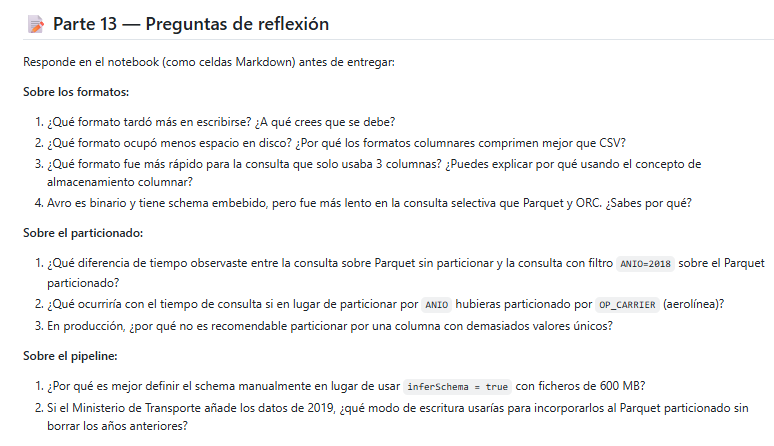

Sobre los formatos:
¿Qué formato tardó más en escribirse? ¿A qué crees que se debe?

 CSV (especialmente si es consolidado). Se debe a que es un formato de texto plano sin compresión nativa, lo que genera un volumen de escritura en disco mucho mayor (I/O) en comparación con formatos binarios.
 ¿Qué formato ocupó menos espacio en disco? ¿Por qué los formatos columnares comprimen mejor que CSV?Parquet. Los formatos columnares comprimen mejor porque agrupan datos del mismo tipo en bloques contiguos. Esto permite aplicar algoritmos de compresión muy eficientes (como RLE o Diccionarios) sobre valores similares, algo imposible en un CSV donde los tipos de datos están mezclados por filas.¿Qué formato fue más rápido para la consulta que solo usaba 3 columnas? ¿Puedes explicarlo con el concepto de almacenamiento columnar?
 Parquet. Gracias al almacenamiento columnar, Spark solo lee del disco las columnas necesarias para la consulta, ignorando físicamente el resto de las columnas del archivo. Esto reduce drásticamente el tráfico de datos.Avro es binario y tiene schema embebido, pero fue más lento en la consulta selectiva que Parquet y ORC.
  ¿Sabes por qué?Porque Avro es un formato basado en filas (row-based). Para extraer solo 3 columnas, Avro tiene que leer la fila completa (todas las columnas) de cada registro, lo que genera mucha más carga de trabajo de lectura que un formato columnar.

Sobre el particionado:
¿Qué diferencia de tiempo observaste entre la consulta sobre Parquet sin particionar y la consulta con filtro ANIO=2018 sobre el Parquet particionado?La consulta sobre el Parquet particionado es significativamente más rápida. Esto se debe al Partition Pruning (poda de particiones): Spark va directamente a la carpeta del año 2018 e ignora por completo los datos de los demás años.
¿Qué ocurriría con el tiempo de consulta si en lugar de particionar por ANIO hubieras particionado por OP_CARRIER (aerolínea)?Las consultas filtradas por aerolínea serían muy rápidas, pero las consultas filtradas por año serían mucho más lentas, ya que Spark tendría que escanear todas las carpetas de todas las aerolíneas para encontrar los datos de un año específico.
En producción, ¿por qué no es recomendable particionar por una columna con demasiados valores únicos (Alta Cardinalidad)?Porque genera el problema de "Muchos archivos pequeños". Se crean miles de carpetas y archivos minúsculos, lo que sobrecarga el sistema de archivos (NameNode en HDFS o Metastore en Hive) y degrada el rendimiento de Spark al gestionar tanta metadata.

Sobre el pipeline:
¿Por qué es mejor definir el schema manualmente en lugar de usar inferSchema = true con ficheros de 600 MB?Porque inferSchema requiere que Spark realice dos pasadas sobre los archivos: una para adivinar los tipos de datos y otra para leerlos realmente. En archivos de 600 MB, esto duplica el tiempo de I/O innecesariamente.
Si el Ministerio de Transporte añade los datos de 2019, ¿qué modo de escritura usarías para incorporarlos al Parquet particionado sin borrar los años anteriores?Se debe usar el modo .mode("append"). Esto añadirá la nueva carpeta ANIO=2019 al Data Lake existente sin afectar a las particiones de los años previos.

In [2]:
// CELDA 1 — Inicialización
import $ivy.`org.apache.spark::spark-core:4.1.1`
import $ivy.`org.apache.spark::spark-sql:4.1.1`

import org.apache.spark.sql.SparkSession
import org.apache.spark.sql.functions._
import org.apache.spark.sql.types._
import java.nio.file.{Files, Paths}
import java.nio.charset.StandardCharsets
import java.io.File

val spark = SparkSession.builder()
  .appName("RapidX_BI_Pipeline")
  .master("local[*]")
  .config("spark.ui.showConsoleProgress", "false")
  .config("spark.sql.shuffle.partitions", "4")
  .getOrCreate()

import spark.implicits._

spark.sparkContext.setLogLevel("ERROR")

println(s"✅ Spark ${spark.version} listo — RapidX BI Pipeline")

✅ Spark 4.1.1 listo — RapidX BI Pipeline


import $ivy.$
import $ivy.$
import org.apache.spark.sql.SparkSession
import org.apache.spark.sql.functions._
import org.apache.spark.sql.types._
import java.nio.file.{Files, Paths}
import java.nio.charset.StandardCharsets
import java.io.File
spark: SparkSession = org.apache.spark.sql.classic.SparkSession@50643200
import spark.implicits._

Case de estudio 3 - RapidX: Pipeline JSON → Parquet → BI
🌍 Contexto de negocio
RapidX es una plataforma de movilidad urbana bajo demanda, similar a Uber, que opera en cinco ciudades españolas. Los sistemas operacionales de RapidX generan un fichero JSON por ciudad cada día. Esos ficheros acumulan todos los viajes completados, cancelados y en curso de esa jornada.

El equipo de Ingeniería de Datos ha recibido el siguiente encargo del departamento de Business Intelligence (BI):

"Necesitamos una vista limpia y enriquecida de los viajes para poder responder preguntas de negocio desde SQL. Los JSONs operacionales tienen ruido, campos internos y columnas que no necesitamos. Queremos un Parquet final con solo las columnas relevantes, particionado por ciudad, que podamos consultar con Spark SQL."

Tu tarea como ingeniero de datos:

Generar los 7 ficheros JSON sintéticos que simulan los datos operacionales de RapidX.
Leer todos los JSON con Spark y construir el DataFrame raw.
Enriquecer el DataFrame añadiendo lógica de negocio con funciones de Spark.
Seleccionar solo las columnas que necesita el equipo de BI (descartar las operacionales).
Escribir el resultado final como Parquet particionado por ciudad.
Exponer el Parquet como vista SQL y responder las preguntas de negocio del equipo de BI.

In [3]:
// CELDA 2 — Carpetas de trabajo
val rutaBase   = "C:/Curso-Scala/datos/rapidx"
val rutaJSON   = s"$rutaBase/json_raw"
val rutaSalida = s"$rutaBase/salida"

List(rutaJSON, rutaSalida).foreach { c =>
  Files.createDirectories(Paths.get(c))
  println(s"  📁 $c")
}

println("\n✅ Estructura de carpetas lista")

  📁 C:/Curso-Scala/datos/rapidx/json_raw
  📁 C:/Curso-Scala/datos/rapidx/salida

✅ Estructura de carpetas lista


rutaBase: String = "C:/Curso-Scala/datos/rapidx"
rutaJSON: String = "C:/Curso-Scala/datos/rapidx/json_raw"
rutaSalida: String = "C:/Curso-Scala/datos/rapidx/salida"

In [4]:
// CELDA 3.1 — JSON Madrid día 1
val jsonMadrid1 =
"""[
  {"viaje_id":"VJ-M-0001","timestamp_inicio":"2024-11-01T07:12:33","timestamp_fin":"2024-11-01T07:38:55","ciudad":"Madrid","zona_origen":"Chamberí","zona_destino":"Retiro","distancia_km":4.8,"duracion_min":26,"tarifa_base":6.40,"propina":1.20,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-441","pasajero_id":"PAX-9921","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-MAD"},
  {"viaje_id":"VJ-M-0002","timestamp_inicio":"2024-11-01T08:05:10","timestamp_fin":"2024-11-01T08:29:40","ciudad":"Madrid","zona_origen":"Sol","zona_destino":"Moncloa","distancia_km":3.2,"duracion_min":24,"tarifa_base":5.10,"propina":0.0,"metodo_pago":"efectivo","estado":"completado","calificacion_pasajero":4,"calificacion_conductor":4,"conductor_id":"DRV-207","pasajero_id":"PAX-3341","tipo_vehiculo":"UberX","surge_multiplier":1.2,"_sys_version":"v3.2","_batch_id":"BAT-20241101-MAD"},
  {"viaje_id":"VJ-M-0003","timestamp_inicio":"2024-11-01T08:45:00","timestamp_fin":null,"ciudad":"Madrid","zona_origen":"Vallecas","zona_destino":"Barajas","distancia_km":0.0,"duracion_min":0,"tarifa_base":0.0,"propina":0.0,"metodo_pago":"tarjeta","estado":"cancelado","calificacion_pasajero":null,"calificacion_conductor":null,"conductor_id":"DRV-119","pasajero_id":"PAX-5512","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-MAD"},
  {"viaje_id":"VJ-M-0004","timestamp_inicio":"2024-11-01T09:30:15","timestamp_fin":"2024-11-01T10:05:50","ciudad":"Madrid","zona_origen":"Salamanca","zona_destino":"Tetuán","distancia_km":6.1,"duracion_min":35,"tarifa_base":9.20,"propina":2.00,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-441","pasajero_id":"PAX-7720","tipo_vehiculo":"UberComfort","surge_multiplier":1.5,"_sys_version":"v3.2","_batch_id":"BAT-20241101-MAD"},
  {"viaje_id":"VJ-M-0005","timestamp_inicio":"2024-11-01T11:00:00","timestamp_fin":"2024-11-01T11:18:30","ciudad":"Madrid","zona_origen":"Arganzuela","zona_destino":"Centro","distancia_km":2.9,"duracion_min":18,"tarifa_base":4.80,"propina":0.50,"metodo_pago":"app_wallet","estado":"completado","calificacion_pasajero":4,"calificacion_conductor":5,"conductor_id":"DRV-332","pasajero_id":"PAX-1102","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-MAD"},
  {"viaje_id":"VJ-M-0006","timestamp_inicio":"2024-11-01T12:15:44","timestamp_fin":"2024-11-01T12:55:10","ciudad":"Madrid","zona_origen":"Barajas","zona_destino":"Chamartín","distancia_km":11.3,"duracion_min":39,"tarifa_base":14.50,"propina":3.00,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":4,"conductor_id":"DRV-207","pasajero_id":"PAX-8841","tipo_vehiculo":"UberXL","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-MAD"},
  {"viaje_id":"VJ-M-0007","timestamp_inicio":"2024-11-01T14:00:00","timestamp_fin":"2024-11-01T14:22:00","ciudad":"Madrid","zona_origen":"Hortaleza","zona_destino":"Retiro","distancia_km":7.7,"duracion_min":22,"tarifa_base":10.10,"propina":0.0,"metodo_pago":"efectivo","estado":"completado","calificacion_pasajero":3,"calificacion_conductor":5,"conductor_id":"DRV-885","pasajero_id":"PAX-2230","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-MAD"},
  {"viaje_id":"VJ-M-0008","timestamp_inicio":"2024-11-01T17:30:00","timestamp_fin":"2024-11-01T18:10:20","ciudad":"Madrid","zona_origen":"Centro","zona_destino":"Vallecas","distancia_km":8.9,"duracion_min":40,"tarifa_base":12.00,"propina":2.50,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-119","pasajero_id":"PAX-4410","tipo_vehiculo":"UberComfort","surge_multiplier":2.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-MAD"},
  {"viaje_id":"VJ-M-0009","timestamp_inicio":"2024-11-01T19:45:00","timestamp_fin":null,"ciudad":"Madrid","zona_origen":"Moncloa","zona_destino":"Sol","distancia_km":0.0,"duracion_min":0,"tarifa_base":0.0,"propina":0.0,"metodo_pago":"app_wallet","estado":"cancelado","calificacion_pasajero":null,"calificacion_conductor":null,"conductor_id":"DRV-332","pasajero_id":"PAX-6631","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-MAD"},
  {"viaje_id":"VJ-M-0010","timestamp_inicio":"2024-11-01T22:10:05","timestamp_fin":"2024-11-01T22:45:30","ciudad":"Madrid","zona_origen":"Retiro","zona_destino":"Salamanca","distancia_km":3.5,"duracion_min":35,"tarifa_base":7.80,"propina":1.50,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":4,"calificacion_conductor":4,"conductor_id":"DRV-441","pasajero_id":"PAX-9921","tipo_vehiculo":"UberX","surge_multiplier":1.8,"_sys_version":"v3.2","_batch_id":"BAT-20241101-MAD"}
]"""

val ruta1 = s"$rutaJSON/viajes_madrid_2024-11-01.json"
Files.write(Paths.get(ruta1), jsonMadrid1.getBytes(StandardCharsets.UTF_8))
println(s"✅ Creado: $ruta1")

✅ Creado: C:/Curso-Scala/datos/rapidx/json_raw/viajes_madrid_2024-11-01.json


jsonMadrid1: String = """[
  {"viaje_id":"VJ-M-0001","timestamp_inicio":"2024-11-01T07:12:33","timestamp_fin":"2024-11-01T07:38:55","ciudad":"Madrid","zona_origen":"Chamberí","zona_destino":"Retiro","distancia_km":4.8,"duracion_min":26,"tarifa_base":6.40,"propina":1.20,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-441","pasajero_id":"PAX-9921","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-MAD"},
  {"viaje_id":"VJ-M-0002","timestamp_inicio":"2024-11-01T08:05:10","timestamp_fin":"2024-11-01T08:29:40","ciudad":"Madrid","zona_origen":"Sol","zona_destino":"Moncloa","distancia_km":3.2,"duracion_min":24,"tarifa_base":5.10,"propina":0.0,"metodo_pago":"efectivo","estado":"completado","calificacion_pasajero":4,"calificacion_conductor":4,"conductor_id":"DRV-207","pasajero_id":"PAX-3341","tipo_vehiculo":"UberX","surge_multiplier":1.2,"_sys_version":"v3.2","_batch_id":"BAT-20241

In [5]:
// CELDA 3.2 — JSON Madrid día 2
val jsonMadrid2 =
"""[
  {"viaje_id":"VJ-M-0011","timestamp_inicio":"2024-11-02T06:55:00","timestamp_fin":"2024-11-02T07:25:10","ciudad":"Madrid","zona_origen":"Tetuán","zona_destino":"Chamartín","distancia_km":4.1,"duracion_min":30,"tarifa_base":6.80,"propina":0.0,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":4,"calificacion_conductor":4,"conductor_id":"DRV-207","pasajero_id":"PAX-1102","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241102-MAD"},
  {"viaje_id":"VJ-M-0012","timestamp_inicio":"2024-11-02T08:20:00","timestamp_fin":"2024-11-02T09:00:45","ciudad":"Madrid","zona_origen":"Barajas","zona_destino":"Centro","distancia_km":14.2,"duracion_min":40,"tarifa_base":18.50,"propina":4.00,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-119","pasajero_id":"PAX-7720","tipo_vehiculo":"UberXL","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241102-MAD"},
  {"viaje_id":"VJ-M-0013","timestamp_inicio":"2024-11-02T10:00:00","timestamp_fin":"2024-11-02T10:19:30","ciudad":"Madrid","zona_origen":"Retiro","zona_destino":"Arganzuela","distancia_km":3.3,"duracion_min":19,"tarifa_base":5.60,"propina":1.00,"metodo_pago":"app_wallet","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-885","pasajero_id":"PAX-3341","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241102-MAD"},
  {"viaje_id":"VJ-M-0014","timestamp_inicio":"2024-11-02T13:30:00","timestamp_fin":"2024-11-02T14:10:00","ciudad":"Madrid","zona_origen":"Salamanca","zona_destino":"Vallecas","distancia_km":9.2,"duracion_min":40,"tarifa_base":13.40,"propina":2.00,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":4,"calificacion_conductor":5,"conductor_id":"DRV-441","pasajero_id":"PAX-5512","tipo_vehiculo":"UberComfort","surge_multiplier":1.3,"_sys_version":"v3.2","_batch_id":"BAT-20241102-MAD"},
  {"viaje_id":"VJ-M-0015","timestamp_inicio":"2024-11-02T18:45:00","timestamp_fin":"2024-11-02T19:30:00","ciudad":"Madrid","zona_origen":"Centro","zona_destino":"Moncloa","distancia_km":5.5,"duracion_min":45,"tarifa_base":9.90,"propina":0.0,"metodo_pago":"efectivo","estado":"completado","calificacion_pasajero":3,"calificacion_conductor":4,"conductor_id":"DRV-332","pasajero_id":"PAX-8841","tipo_vehiculo":"UberX","surge_multiplier":1.9,"_sys_version":"v3.2","_batch_id":"BAT-20241102-MAD"}
]"""

val ruta2 = s"$rutaJSON/viajes_madrid_2024-11-02.json"
Files.write(Paths.get(ruta2), jsonMadrid2.getBytes(StandardCharsets.UTF_8))
println(s"✅ Creado: $ruta2")

✅ Creado: C:/Curso-Scala/datos/rapidx/json_raw/viajes_madrid_2024-11-02.json


jsonMadrid2: String = """[
  {"viaje_id":"VJ-M-0011","timestamp_inicio":"2024-11-02T06:55:00","timestamp_fin":"2024-11-02T07:25:10","ciudad":"Madrid","zona_origen":"Tetuán","zona_destino":"Chamartín","distancia_km":4.1,"duracion_min":30,"tarifa_base":6.80,"propina":0.0,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":4,"calificacion_conductor":4,"conductor_id":"DRV-207","pasajero_id":"PAX-1102","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241102-MAD"},
  {"viaje_id":"VJ-M-0012","timestamp_inicio":"2024-11-02T08:20:00","timestamp_fin":"2024-11-02T09:00:45","ciudad":"Madrid","zona_origen":"Barajas","zona_destino":"Centro","distancia_km":14.2,"duracion_min":40,"tarifa_base":18.50,"propina":4.00,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-119","pasajero_id":"PAX-7720","tipo_vehiculo":"UberXL","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT

In [6]:
// CELDA 3.3 — JSON Barcelona
val jsonBarcelona =
"""[
  {"viaje_id":"VJ-B-0001","timestamp_inicio":"2024-11-01T07:30:00","timestamp_fin":"2024-11-01T08:00:15","ciudad":"Barcelona","zona_origen":"Gràcia","zona_destino":"Eixample","distancia_km":3.1,"duracion_min":30,"tarifa_base":5.80,"propina":1.00,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-610","pasajero_id":"PAX-2201","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-BCN"},
  {"viaje_id":"VJ-B-0002","timestamp_inicio":"2024-11-01T09:00:00","timestamp_fin":"2024-11-01T09:35:20","ciudad":"Barcelona","zona_origen":"Sants","zona_destino":"Barceloneta","distancia_km":5.7,"duracion_min":35,"tarifa_base":8.30,"propina":0.0,"metodo_pago":"efectivo","estado":"completado","calificacion_pasajero":4,"calificacion_conductor":3,"conductor_id":"DRV-730","pasajero_id":"PAX-4410","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-BCN"},
  {"viaje_id":"VJ-B-0003","timestamp_inicio":"2024-11-01T10:10:00","timestamp_fin":null,"ciudad":"Barcelona","zona_origen":"Sagrada Familia","zona_destino":"Gràcia","distancia_km":0.0,"duracion_min":0,"tarifa_base":0.0,"propina":0.0,"metodo_pago":"app_wallet","estado":"cancelado","calificacion_pasajero":null,"calificacion_conductor":null,"conductor_id":"DRV-610","pasajero_id":"PAX-6631","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-BCN"},
  {"viaje_id":"VJ-B-0004","timestamp_inicio":"2024-11-01T12:00:00","timestamp_fin":"2024-11-01T12:50:00","ciudad":"Barcelona","zona_origen":"Eixample","zona_destino":"Aeropuerto BCN","distancia_km":15.8,"duracion_min":50,"tarifa_base":22.00,"propina":5.00,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-850","pasajero_id":"PAX-9921","tipo_vehiculo":"UberXL","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-BCN"},
  {"viaje_id":"VJ-B-0005","timestamp_inicio":"2024-11-01T14:30:00","timestamp_fin":"2024-11-01T14:55:10","ciudad":"Barcelona","zona_origen":"Barceloneta","zona_destino":"Poblenou","distancia_km":4.2,"duracion_min":25,"tarifa_base":6.90,"propina":1.50,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":4,"calificacion_conductor":5,"conductor_id":"DRV-730","pasajero_id":"PAX-2201","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-BCN"},
  {"viaje_id":"VJ-B-0006","timestamp_inicio":"2024-11-01T18:00:00","timestamp_fin":"2024-11-01T18:40:00","ciudad":"Barcelona","zona_origen":"Sants","zona_destino":"Sagrada Familia","distancia_km":6.3,"duracion_min":40,"tarifa_base":10.20,"propina":2.00,"metodo_pago":"app_wallet","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-610","pasajero_id":"PAX-3341","tipo_vehiculo":"UberComfort","surge_multiplier":1.6,"_sys_version":"v3.2","_batch_id":"BAT-20241101-BCN"},
  {"viaje_id":"VJ-B-0007","timestamp_inicio":"2024-11-01T20:15:00","timestamp_fin":"2024-11-01T20:45:30","ciudad":"Barcelona","zona_origen":"Poblenou","zona_destino":"Eixample","distancia_km":5.0,"duracion_min":30,"tarifa_base":8.50,"propina":0.0,"metodo_pago":"efectivo","estado":"completado","calificacion_pasajero":3,"calificacion_conductor":4,"conductor_id":"DRV-850","pasajero_id":"PAX-7720","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-BCN"}
]"""

val ruta3 = s"$rutaJSON/viajes_barcelona_2024-11-01.json"
Files.write(Paths.get(ruta3), jsonBarcelona.getBytes(StandardCharsets.UTF_8))
println(s"✅ Creado: $ruta3")

✅ Creado: C:/Curso-Scala/datos/rapidx/json_raw/viajes_barcelona_2024-11-01.json


jsonBarcelona: String = """[
  {"viaje_id":"VJ-B-0001","timestamp_inicio":"2024-11-01T07:30:00","timestamp_fin":"2024-11-01T08:00:15","ciudad":"Barcelona","zona_origen":"Gràcia","zona_destino":"Eixample","distancia_km":3.1,"duracion_min":30,"tarifa_base":5.80,"propina":1.00,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-610","pasajero_id":"PAX-2201","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-BCN"},
  {"viaje_id":"VJ-B-0002","timestamp_inicio":"2024-11-01T09:00:00","timestamp_fin":"2024-11-01T09:35:20","ciudad":"Barcelona","zona_origen":"Sants","zona_destino":"Barceloneta","distancia_km":5.7,"duracion_min":35,"tarifa_base":8.30,"propina":0.0,"metodo_pago":"efectivo","estado":"completado","calificacion_pasajero":4,"calificacion_conductor":3,"conductor_id":"DRV-730","pasajero_id":"PAX-4410","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_

In [7]:
// CELDA 3.4 — JSON Sevilla
val jsonSevilla =
"""[
  {"viaje_id":"VJ-S-0001","timestamp_inicio":"2024-11-01T08:00:00","timestamp_fin":"2024-11-01T08:22:00","ciudad":"Sevilla","zona_origen":"Triana","zona_destino":"Centro","distancia_km":3.5,"duracion_min":22,"tarifa_base":5.20,"propina":0.50,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-561","pasajero_id":"PAX-1102","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-SVQ"},
  {"viaje_id":"VJ-S-0002","timestamp_inicio":"2024-11-01T09:30:00","timestamp_fin":"2024-11-01T10:05:00","ciudad":"Sevilla","zona_origen":"Macarena","zona_destino":"Aeropuerto SVQ","distancia_km":9.8,"duracion_min":35,"tarifa_base":12.50,"propina":2.00,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":4,"calificacion_conductor":5,"conductor_id":"DRV-623","pasajero_id":"PAX-4410","tipo_vehiculo":"UberXL","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-SVQ"},
  {"viaje_id":"VJ-S-0003","timestamp_inicio":"2024-11-01T11:00:00","timestamp_fin":null,"ciudad":"Sevilla","zona_origen":"Nervión","zona_destino":"Triana","distancia_km":0.0,"duracion_min":0,"tarifa_base":0.0,"propina":0.0,"metodo_pago":"app_wallet","estado":"cancelado","calificacion_pasajero":null,"calificacion_conductor":null,"conductor_id":"DRV-561","pasajero_id":"PAX-8841","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-SVQ"},
  {"viaje_id":"VJ-S-0004","timestamp_inicio":"2024-11-01T13:15:00","timestamp_fin":"2024-11-01T13:40:00","ciudad":"Sevilla","zona_origen":"Centro","zona_destino":"Nervión","distancia_km":4.2,"duracion_min":25,"tarifa_base":6.30,"propina":1.00,"metodo_pago":"efectivo","estado":"completado","calificacion_pasajero":4,"calificacion_conductor":4,"conductor_id":"DRV-623","pasajero_id":"PAX-2230","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-SVQ"},
  {"viaje_id":"VJ-S-0005","timestamp_inicio":"2024-11-01T17:00:00","timestamp_fin":"2024-11-01T17:28:00","ciudad":"Sevilla","zona_origen":"Triana","zona_destino":"Macarena","distancia_km":5.1,"duracion_min":28,"tarifa_base":7.80,"propina":0.0,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-561","pasajero_id":"PAX-6631","tipo_vehiculo":"UberComfort","surge_multiplier":1.4,"_sys_version":"v3.2","_batch_id":"BAT-20241101-SVQ"}
]"""

val ruta4 = s"$rutaJSON/viajes_sevilla_2024-11-01.json"
Files.write(Paths.get(ruta4), jsonSevilla.getBytes(StandardCharsets.UTF_8))
println(s"✅ Creado: $ruta4")

✅ Creado: C:/Curso-Scala/datos/rapidx/json_raw/viajes_sevilla_2024-11-01.json


jsonSevilla: String = """[
  {"viaje_id":"VJ-S-0001","timestamp_inicio":"2024-11-01T08:00:00","timestamp_fin":"2024-11-01T08:22:00","ciudad":"Sevilla","zona_origen":"Triana","zona_destino":"Centro","distancia_km":3.5,"duracion_min":22,"tarifa_base":5.20,"propina":0.50,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-561","pasajero_id":"PAX-1102","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-SVQ"},
  {"viaje_id":"VJ-S-0002","timestamp_inicio":"2024-11-01T09:30:00","timestamp_fin":"2024-11-01T10:05:00","ciudad":"Sevilla","zona_origen":"Macarena","zona_destino":"Aeropuerto SVQ","distancia_km":9.8,"duracion_min":35,"tarifa_base":12.50,"propina":2.00,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":4,"calificacion_conductor":5,"conductor_id":"DRV-623","pasajero_id":"PAX-4410","tipo_vehiculo":"UberXL","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_

In [8]:
// CELDA 3.5 — JSON Valencia
val jsonValencia =
"""[
  {"viaje_id":"VJ-V-0001","timestamp_inicio":"2024-11-01T07:00:00","timestamp_fin":"2024-11-01T07:30:00","ciudad":"Valencia","zona_origen":"Ruzafa","zona_destino":"Ciudad de las Artes","distancia_km":4.5,"duracion_min":30,"tarifa_base":7.10,"propina":1.00,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-712","pasajero_id":"PAX-5512","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-VLC"},
  {"viaje_id":"VJ-V-0002","timestamp_inicio":"2024-11-01T08:30:00","timestamp_fin":"2024-11-01T09:10:00","ciudad":"Valencia","zona_origen":"Aeropuerto VLC","zona_destino":"Centro","distancia_km":10.2,"duracion_min":40,"tarifa_base":14.00,"propina":3.00,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":4,"calificacion_conductor":5,"conductor_id":"DRV-803","pasajero_id":"PAX-9921","tipo_vehiculo":"UberXL","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-VLC"},
  {"viaje_id":"VJ-V-0003","timestamp_inicio":"2024-11-01T10:00:00","timestamp_fin":"2024-11-01T10:20:00","ciudad":"Valencia","zona_origen":"Benimaclet","zona_destino":"Ruzafa","distancia_km":5.8,"duracion_min":20,"tarifa_base":8.20,"propina":0.0,"metodo_pago":"efectivo","estado":"completado","calificacion_pasajero":3,"calificacion_conductor":4,"conductor_id":"DRV-712","pasajero_id":"PAX-3341","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-VLC"},
  {"viaje_id":"VJ-V-0004","timestamp_inicio":"2024-11-01T12:00:00","timestamp_fin":null,"ciudad":"Valencia","zona_origen":"Centro","zona_destino":"Puerto","distancia_km":0.0,"duracion_min":0,"tarifa_base":0.0,"propina":0.0,"metodo_pago":"app_wallet","estado":"cancelado","calificacion_pasajero":null,"calificacion_conductor":null,"conductor_id":"DRV-803","pasajero_id":"PAX-2201","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-VLC"},
  {"viaje_id":"VJ-V-0005","timestamp_inicio":"2024-11-01T15:30:00","timestamp_fin":"2024-11-01T15:55:00","ciudad":"Valencia","zona_origen":"Ciudad de las Artes","zona_destino":"Benimaclet","distancia_km":6.9,"duracion_min":25,"tarifa_base":9.50,"propina":2.00,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-712","pasajero_id":"PAX-7720","tipo_vehiculo":"UberComfort","surge_multiplier":1.2,"_sys_version":"v3.2","_batch_id":"BAT-20241101-VLC"},
  {"viaje_id":"VJ-V-0006","timestamp_inicio":"2024-11-01T19:00:00","timestamp_fin":"2024-11-01T19:35:00","ciudad":"Valencia","zona_origen":"Puerto","zona_destino":"Centro","distancia_km":4.0,"duracion_min":35,"tarifa_base":7.60,"propina":0.0,"metodo_pago":"efectivo","estado":"completado","calificacion_pasajero":4,"calificacion_conductor":4,"conductor_id":"DRV-803","pasajero_id":"PAX-4410","tipo_vehiculo":"UberX","surge_multiplier":1.7,"_sys_version":"v3.2","_batch_id":"BAT-20241101-VLC"}
]"""

val ruta5 = s"$rutaJSON/viajes_valencia_2024-11-01.json"
Files.write(Paths.get(ruta5), jsonValencia.getBytes(StandardCharsets.UTF_8))
println(s"✅ Creado: $ruta5")

✅ Creado: C:/Curso-Scala/datos/rapidx/json_raw/viajes_valencia_2024-11-01.json


jsonValencia: String = """[
  {"viaje_id":"VJ-V-0001","timestamp_inicio":"2024-11-01T07:00:00","timestamp_fin":"2024-11-01T07:30:00","ciudad":"Valencia","zona_origen":"Ruzafa","zona_destino":"Ciudad de las Artes","distancia_km":4.5,"duracion_min":30,"tarifa_base":7.10,"propina":1.00,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-712","pasajero_id":"PAX-5512","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-VLC"},
  {"viaje_id":"VJ-V-0002","timestamp_inicio":"2024-11-01T08:30:00","timestamp_fin":"2024-11-01T09:10:00","ciudad":"Valencia","zona_origen":"Aeropuerto VLC","zona_destino":"Centro","distancia_km":10.2,"duracion_min":40,"tarifa_base":14.00,"propina":3.00,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":4,"calificacion_conductor":5,"conductor_id":"DRV-803","pasajero_id":"PAX-9921","tipo_vehiculo":"UberXL","surge_multiplier":1.0,"_sys_version":

In [9]:
// CELDA 3.6 — JSON Bilbao
val jsonBilbao =
"""[
  {"viaje_id":"VJ-BI-0001","timestamp_inicio":"2024-11-01T07:45:00","timestamp_fin":"2024-11-01T08:10:00","ciudad":"Bilbao","zona_origen":"Casco Viejo","zona_destino":"Guggenheim","distancia_km":2.8,"duracion_min":25,"tarifa_base":5.50,"propina":1.00,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-910","pasajero_id":"PAX-1102","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-BIO"},
  {"viaje_id":"VJ-BI-0002","timestamp_inicio":"2024-11-01T09:00:00","timestamp_fin":"2024-11-01T09:45:00","ciudad":"Bilbao","zona_origen":"Aeropuerto BIO","zona_destino":"Centro","distancia_km":11.5,"duracion_min":45,"tarifa_base":15.80,"propina":2.50,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":4,"calificacion_conductor":5,"conductor_id":"DRV-975","pasajero_id":"PAX-8841","tipo_vehiculo":"UberXL","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-BIO"},
  {"viaje_id":"VJ-BI-0003","timestamp_inicio":"2024-11-01T11:00:00","timestamp_fin":"2024-11-01T11:22:00","ciudad":"Bilbao","zona_origen":"Guggenheim","zona_destino":"Indautxu","distancia_km":3.3,"duracion_min":22,"tarifa_base":5.90,"propina":0.0,"metodo_pago":"app_wallet","estado":"completado","calificacion_pasajero":4,"calificacion_conductor":4,"conductor_id":"DRV-910","pasajero_id":"PAX-6631","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-BIO"},
  {"viaje_id":"VJ-BI-0004","timestamp_inicio":"2024-11-01T14:00:00","timestamp_fin":"2024-11-01T14:35:00","ciudad":"Bilbao","zona_origen":"Indautxu","zona_destino":"Casco Viejo","distancia_km":4.8,"duracion_min":35,"tarifa_base":8.10,"propina":1.50,"metodo_pago":"efectivo","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-975","pasajero_id":"PAX-2230","tipo_vehiculo":"UberComfort","surge_multiplier":1.3,"_sys_version":"v3.2","_batch_id":"BAT-20241101-BIO"},
  {"viaje_id":"VJ-BI-0005","timestamp_inicio":"2024-11-01T17:30:00","timestamp_fin":null,"ciudad":"Bilbao","zona_origen":"Centro","zona_destino":"Aeropuerto BIO","distancia_km":0.0,"duracion_min":0,"tarifa_base":0.0,"propina":0.0,"metodo_pago":"tarjeta","estado":"cancelado","calificacion_pasajero":null,"calificacion_conductor":null,"conductor_id":"DRV-910","pasajero_id":"PAX-3341","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-BIO"}
]"""

val ruta6 = s"$rutaJSON/viajes_bilbao_2024-11-01.json"
Files.write(Paths.get(ruta6), jsonBilbao.getBytes(StandardCharsets.UTF_8))
println(s"✅ Creado: $ruta6")

✅ Creado: C:/Curso-Scala/datos/rapidx/json_raw/viajes_bilbao_2024-11-01.json


jsonBilbao: String = """[
  {"viaje_id":"VJ-BI-0001","timestamp_inicio":"2024-11-01T07:45:00","timestamp_fin":"2024-11-01T08:10:00","ciudad":"Bilbao","zona_origen":"Casco Viejo","zona_destino":"Guggenheim","distancia_km":2.8,"duracion_min":25,"tarifa_base":5.50,"propina":1.00,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-910","pasajero_id":"PAX-1102","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.2","_batch_id":"BAT-20241101-BIO"},
  {"viaje_id":"VJ-BI-0002","timestamp_inicio":"2024-11-01T09:00:00","timestamp_fin":"2024-11-01T09:45:00","ciudad":"Bilbao","zona_origen":"Aeropuerto BIO","zona_destino":"Centro","distancia_km":11.5,"duracion_min":45,"tarifa_base":15.80,"propina":2.50,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":4,"calificacion_conductor":5,"conductor_id":"DRV-975","pasajero_id":"PAX-8841","tipo_vehiculo":"UberXL","surge_multiplier":1.0,"_sys_version":"v3.2","

In [10]:
// CELDA 3.7 — JSON multi-ciudad día 3
val jsonMultiCiudad =
"""[
  {"viaje_id":"VJ-M-0020","timestamp_inicio":"2024-11-03T08:00:00","timestamp_fin":"2024-11-03T08:30:00","ciudad":"Madrid","zona_origen":"Sol","zona_destino":"Retiro","distancia_km":3.8,"duracion_min":30,"tarifa_base":6.20,"propina":1.00,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-441","pasajero_id":"PAX-2201","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.3","_batch_id":"BAT-20241103-ALL"},
  {"viaje_id":"VJ-B-0010","timestamp_inicio":"2024-11-03T09:15:00","timestamp_fin":"2024-11-03T09:50:00","ciudad":"Barcelona","zona_origen":"Eixample","zona_destino":"Sants","distancia_km":5.2,"duracion_min":35,"tarifa_base":8.80,"propina":0.0,"metodo_pago":"app_wallet","estado":"completado","calificacion_pasajero":4,"calificacion_conductor":4,"conductor_id":"DRV-610","pasajero_id":"PAX-4410","tipo_vehiculo":"UberX","surge_multiplier":1.1,"_sys_version":"v3.3","_batch_id":"BAT-20241103-ALL"},
  {"viaje_id":"VJ-S-0010","timestamp_inicio":"2024-11-03T10:00:00","timestamp_fin":"2024-11-03T10:25:00","ciudad":"Sevilla","zona_origen":"Nervión","zona_destino":"Centro","distancia_km":4.0,"duracion_min":25,"tarifa_base":6.50,"propina":0.50,"metodo_pago":"efectivo","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-623","pasajero_id":"PAX-7720","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.3","_batch_id":"BAT-20241103-ALL"},
  {"viaje_id":"VJ-V-0010","timestamp_inicio":"2024-11-03T11:00:00","timestamp_fin":"2024-11-03T11:40:00","ciudad":"Valencia","zona_origen":"Centro","zona_destino":"Aeropuerto VLC","distancia_km":10.5,"duracion_min":40,"tarifa_base":14.80,"propina":3.50,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-803","pasajero_id":"PAX-9921","tipo_vehiculo":"UberXL","surge_multiplier":1.0,"_sys_version":"v3.3","_batch_id":"BAT-20241103-ALL"},
  {"viaje_id":"VJ-BI-0010","timestamp_inicio":"2024-11-03T12:00:00","timestamp_fin":null,"ciudad":"Bilbao","zona_origen":"Guggenheim","zona_destino":"Casco Viejo","distancia_km":0.0,"duracion_min":0,"tarifa_base":0.0,"propina":0.0,"metodo_pago":"tarjeta","estado":"cancelado","calificacion_pasajero":null,"calificacion_conductor":null,"conductor_id":"DRV-975","pasajero_id":"PAX-1102","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.3","_batch_id":"BAT-20241103-ALL"},
  {"viaje_id":"VJ-M-0021","timestamp_inicio":"2024-11-03T14:00:00","timestamp_fin":"2024-11-03T14:45:00","ciudad":"Madrid","zona_origen":"Chamartín","zona_destino":"Barajas","distancia_km":12.0,"duracion_min":45,"tarifa_base":16.00,"propina":4.00,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-332","pasajero_id":"PAX-5512","tipo_vehiculo":"UberXL","surge_multiplier":1.0,"_sys_version":"v3.3","_batch_id":"BAT-20241103-ALL"},
  {"viaje_id":"VJ-B-0011","timestamp_inicio":"2024-11-03T16:30:00","timestamp_fin":"2024-11-03T17:00:00","ciudad":"Barcelona","zona_origen":"Gràcia","zona_destino":"Barceloneta","distancia_km":4.7,"duracion_min":30,"tarifa_base":7.50,"propina":1.50,"metodo_pago":"app_wallet","estado":"completado","calificacion_pasajero":4,"calificacion_conductor":5,"conductor_id":"DRV-730","pasajero_id":"PAX-6631","tipo_vehiculo":"UberComfort","surge_multiplier":1.5,"_sys_version":"v3.3","_batch_id":"BAT-20241103-ALL"},
  {"viaje_id":"VJ-S-0011","timestamp_inicio":"2024-11-03T18:00:00","timestamp_fin":"2024-11-03T18:28:00","ciudad":"Sevilla","zona_origen":"Triana","zona_destino":"Macarena","distancia_km":5.5,"duracion_min":28,"tarifa_base":8.20,"propina":0.0,"metodo_pago":"efectivo","estado":"completado","calificacion_pasajero":3,"calificacion_conductor":4,"conductor_id":"DRV-561","pasajero_id":"PAX-8841","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.3","_batch_id":"BAT-20241103-ALL"}
]"""

val ruta7 = s"$rutaJSON/viajes_todas_ciudades_2024-11-03.json"
Files.write(Paths.get(ruta7), jsonMultiCiudad.getBytes(StandardCharsets.UTF_8))
println(s"✅ Creado: $ruta7")

✅ Creado: C:/Curso-Scala/datos/rapidx/json_raw/viajes_todas_ciudades_2024-11-03.json


jsonMultiCiudad: String = """[
  {"viaje_id":"VJ-M-0020","timestamp_inicio":"2024-11-03T08:00:00","timestamp_fin":"2024-11-03T08:30:00","ciudad":"Madrid","zona_origen":"Sol","zona_destino":"Retiro","distancia_km":3.8,"duracion_min":30,"tarifa_base":6.20,"propina":1.00,"metodo_pago":"tarjeta","estado":"completado","calificacion_pasajero":5,"calificacion_conductor":5,"conductor_id":"DRV-441","pasajero_id":"PAX-2201","tipo_vehiculo":"UberX","surge_multiplier":1.0,"_sys_version":"v3.3","_batch_id":"BAT-20241103-ALL"},
  {"viaje_id":"VJ-B-0010","timestamp_inicio":"2024-11-03T09:15:00","timestamp_fin":"2024-11-03T09:50:00","ciudad":"Barcelona","zona_origen":"Eixample","zona_destino":"Sants","distancia_km":5.2,"duracion_min":35,"tarifa_base":8.80,"propina":0.0,"metodo_pago":"app_wallet","estado":"completado","calificacion_pasajero":4,"calificacion_conductor":4,"conductor_id":"DRV-610","pasajero_id":"PAX-4410","tipo_vehiculo":"UberX","surge_multiplier":1.1,"_sys_version":"v3.3","_batch_id":"BA

In [11]:
// CELDA 3.8 — Verificación
val ficheros = new File(rutaJSON).listFiles().filter(_.getName.endsWith(".json")).sorted
println(s"Ficheros JSON en $rutaJSON:\n")
ficheros.foreach { f =>
  println(f"  ${f.getName}%-45s  ${f.length()} bytes")
}
println(s"\n✅ Total: ${ficheros.length} ficheros JSON listos")

Ficheros JSON en C:/Curso-Scala/datos/rapidx/json_raw:

  viajes_barcelona_2024-11-01.json               3514 bytes
  viajes_bilbao_2024-11-01.json                  2502 bytes
  viajes_madrid_2024-11-01.json                  4938 bytes
  viajes_madrid_2024-11-02.json                  2490 bytes
  viajes_sevilla_2024-11-01.json                 2479 bytes
  viajes_todas_ciudades_2024-11-03.json          3982 bytes
  viajes_valencia_2024-11-01.json                3005 bytes

✅ Total: 7 ficheros JSON listos


ficheros: Array[File] = Array(
  C:\Curso-Scala\datos\rapidx\json_raw\viajes_barcelona_2024-11-01.json,
  C:\Curso-Scala\datos\rapidx\json_raw\viajes_bilbao_2024-11-01.json,
  C:\Curso-Scala\datos\rapidx\json_raw\viajes_madrid_2024-11-01.json,
  C:\Curso-Scala\datos\rapidx\json_raw\viajes_madrid_2024-11-02.json,
  C:\Curso-Scala\datos\rapidx\json_raw\viajes_sevilla_2024-11-01.json,
  C:\Curso-Scala\datos\rapidx\json_raw\viajes_todas_ciudades_2024-11-03.json,
  C:\Curso-Scala\datos\rapidx\json_raw\viajes_valencia_2024-11-01.json
)

In [12]:
// CELDA 4 — Leer todos los JSON
val dfRaw = spark.read
  .option("multiline", "false")   // un objeto JSON por línea — nuestro formato
  .json(s"$rutaJSON/*.json")

println("=== DataFrame RAW cargado desde JSON ===")
println(s"  Filas totales : ${dfRaw.count()}")
println(s"  Columnas      : ${dfRaw.columns.length}")
println()
println("Schema detectado automáticamente:")
dfRaw.printSchema()
println()
dfRaw.show(5, truncate = false)

=== DataFrame RAW cargado desde JSON ===
  Filas totales : 60
  Columnas      : 21

Schema detectado automáticamente:
root
 |-- _batch_id: string (nullable = true)
 |-- _corrupt_record: string (nullable = true)
 |-- _sys_version: string (nullable = true)
 |-- calificacion_conductor: long (nullable = true)
 |-- calificacion_pasajero: long (nullable = true)
 |-- ciudad: string (nullable = true)
 |-- conductor_id: string (nullable = true)
 |-- distancia_km: double (nullable = true)
 |-- duracion_min: long (nullable = true)
 |-- estado: string (nullable = true)
 |-- metodo_pago: string (nullable = true)
 |-- pasajero_id: string (nullable = true)
 |-- propina: double (nullable = true)
 |-- surge_multiplier: double (nullable = true)
 |-- tarifa_base: double (nullable = true)
 |-- timestamp_fin: string (nullable = true)
 |-- timestamp_inicio: string (nullable = true)
 |-- tipo_vehiculo: string (nullable = true)
 |-- viaje_id: string (nullable = true)
 |-- zona_destino: string (nullable = true

dfRaw: org.apache.spark.sql.package.DataFrame = [_batch_id: string, _corrupt_record: string ... 19 more fields]

In [13]:
// CELDA 5 — Enriquecimiento del DataFrame

val dfEnriquecido = dfRaw

  // ── 1. Parsear timestamps a tipo Timestamp ─────────────────────────────
  .withColumn("ts_inicio",  to_timestamp(col("timestamp_inicio"), "yyyy-MM-dd'T'HH:mm:ss"))
  .withColumn("ts_fin",     to_timestamp(col("timestamp_fin"),    "yyyy-MM-dd'T'HH:mm:ss"))

  // ── 2. Extraer fecha y hora de inicio ──────────────────────────────────
  .withColumn("fecha",      to_date(col("ts_inicio")))
  .withColumn("hora_inicio", hour(col("ts_inicio")))

  // ── 3. Franja horaria del viaje ────────────────────────────────────────
  //    Útil para BI: ¿cuándo hay más demanda?
  .withColumn("franja_horaria",
    when(col("hora_inicio").between(6, 9),   "Mañana pico")
    .when(col("hora_inicio").between(10, 13), "Mediodía")
    .when(col("hora_inicio").between(14, 17), "Tarde")
    .when(col("hora_inicio").between(18, 21), "Noche pico")
    .otherwise("Madrugada")
  )

  // ── 4. Importe total (tarifa + propina) ────────────────────────────────
  .withColumn("importe_total",
    round(col("tarifa_base") + col("propina"), 2)
  )

  // ── 5. Importe con surge aplicado ─────────────────────────────────────
  //    La tarifa_base ya lleva el surge, aquí lo dejamos explícito para BI
  .withColumn("importe_con_surge",
    round(col("tarifa_base") * col("surge_multiplier"), 2)
  )

  // ── 6. Indicador de viaje largo (distancia > 10 km) ───────────────────
  .withColumn("es_viaje_largo",
    col("distancia_km") > 10.0
  )

  // ── 7. Indicador de viaje con propina ─────────────────────────────────
  .withColumn("tiene_propina",
    col("propina") > 0.0
  )

  // ── 8. Segmento de calidad del conductor ──────────────────────────────
  //    Basado en calificacion_conductor (solo para viajes completados)
  .withColumn("segmento_conductor",
    when(col("estado") === "cancelado",          "Sin valorar")
    .when(col("calificacion_conductor") === 5,   "Excelente")
    .when(col("calificacion_conductor") >= 4,    "Bueno")
    .when(col("calificacion_conductor") >= 3,    "Aceptable")
    .otherwise("Bajo")
  )

  // ── 9. Indicador de surge activo ──────────────────────────────────────
  .withColumn("surge_activo",
    col("surge_multiplier") > 1.0
  )

  // ── 10. Precio por kilómetro ───────────────────────────────────────────
  //    Para viajes cancelados distancia_km = 0 → null para evitar división por cero
  .withColumn("precio_por_km",
    when(col("distancia_km") > 0.0,
      round(col("tarifa_base") / col("distancia_km"), 2)
    ).otherwise(null)
  )

println("=== DataFrame enriquecido ===")
println(s"  Columnas originales : ${dfRaw.columns.length}")
println(s"  Columnas tras enriquecimiento: ${dfEnriquecido.columns.length}")
println()
dfEnriquecido.select(
  "viaje_id", "ciudad", "fecha", "franja_horaria",
  "importe_total", "es_viaje_largo", "segmento_conductor", "surge_activo", "precio_por_km"
).show(8, truncate = false)

=== DataFrame enriquecido ===
  Columnas originales : 21
  Columnas tras enriquecimiento: 33

+---------+------+----------+--------------+-------------+--------------+------------------+------------+-------------+
|viaje_id |ciudad|fecha     |franja_horaria|importe_total|es_viaje_largo|segmento_conductor|surge_activo|precio_por_km|
+---------+------+----------+--------------+-------------+--------------+------------------+------------+-------------+
|NULL     |NULL  |NULL      |Madrugada     |NULL         |NULL          |Bajo              |NULL        |NULL         |
|VJ-M-0001|Madrid|2024-11-01|Mañana pico   |7.6          |false         |Excelente         |false       |1.33         |
|VJ-M-0002|Madrid|2024-11-01|Mañana pico   |5.1          |false         |Bueno             |true        |1.59         |
|VJ-M-0003|Madrid|2024-11-01|Mañana pico   |0.0          |false         |Sin valorar       |false       |NULL         |
|VJ-M-0004|Madrid|2024-11-01|Mañana pico   |11.2         |false   

dfEnriquecido: org.apache.spark.sql.package.DataFrame = [_batch_id: string, _corrupt_record: string ... 31 more fields]

In [14]:
// CELDA 6 — DataFrame final para BI (columnas seleccionadas)

val dfBI = dfEnriquecido.select(
  // Identificadores
  col("viaje_id"),
  col("fecha"),
  col("hora_inicio"),
  col("franja_horaria"),

  // Geografía
  col("ciudad"),
  col("zona_origen"),
  col("zona_destino"),

  // Operación
  col("tipo_vehiculo"),
  col("estado"),
  col("distancia_km"),
  col("duracion_min"),
  col("es_viaje_largo"),

  // Economía
  col("tarifa_base"),
  col("propina"),
  col("importe_total"),
  col("importe_con_surge"),
  col("surge_multiplier"),
  col("surge_activo"),
  col("tiene_propina"),
  col("precio_por_km"),
  col("metodo_pago"),

  // Calidad
  col("calificacion_pasajero"),
  col("calificacion_conductor"),
  col("segmento_conductor"),

  // Actores (anonimizados — solo IDs)
  col("conductor_id"),
  col("pasajero_id")
  // ❌ Excluidos intencionadamente:
  //   _batch_id       → campo interno del sistema operacional
  //   _sys_version    → campo interno del sistema operacional
  //   timestamp_inicio (String raw) → reemplazado por ts_inicio (Timestamp)
  //   timestamp_fin   (String raw) → reemplazado por ts_fin (Timestamp)
  //   ts_inicio, ts_fin → BI no los necesita, trabajan con fecha y hora_inicio
)

println("=== DataFrame BI final ===")
println(s"  Columnas seleccionadas: ${dfBI.columns.length}")
println(s"  Filas: ${dfBI.count()}")
println()
println("Columnas del DataFrame BI:")
dfBI.columns.zipWithIndex.foreach { case (col, i) =>
  println(f"  ${i + 1}%2d. $col")
}
println()
dfBI.show(5, truncate = true)

=== DataFrame BI final ===
  Columnas seleccionadas: 26
  Filas: 60

Columnas del DataFrame BI:
   1. viaje_id
   2. fecha
   3. hora_inicio
   4. franja_horaria
   5. ciudad
   6. zona_origen
   7. zona_destino
   8. tipo_vehiculo
   9. estado
  10. distancia_km
  11. duracion_min
  12. es_viaje_largo
  13. tarifa_base
  14. propina
  15. importe_total
  16. importe_con_surge
  17. surge_multiplier
  18. surge_activo
  19. tiene_propina
  20. precio_por_km
  21. metodo_pago
  22. calificacion_pasajero
  23. calificacion_conductor
  24. segmento_conductor
  25. conductor_id
  26. pasajero_id

+---------+----------+-----------+--------------+------+-----------+------------+-------------+----------+------------+------------+--------------+-----------+-------+-------------+-----------------+----------------+------------+-------------+-------------+-----------+---------------------+----------------------+------------------+------------+-----------+
| viaje_id|     fecha|hora_inicio|franja_

dfBI: org.apache.spark.sql.package.DataFrame = [viaje_id: string, fecha: date ... 24 more fields]

In [15]:
// CELDA 7 — Escritura Parquet particionado por ciudad
val rutaParquetBI = s"$rutaSalida/parquet_bi"

val inicio = System.nanoTime()

dfBI.write
  .mode("overwrite")
  .partitionBy("ciudad")
  .parquet(rutaParquetBI)

val tiempoMs = (System.nanoTime() - inicio) / 1_000_000L

println(s"✅ Parquet BI escrito en ${tiempoMs} ms")
println(s"   Ruta: $rutaParquetBI")
println()
println("Particiones generadas:")
new File(rutaParquetBI)
  .listFiles()
  .filter(_.isDirectory)
  .map(_.getName)
  .sorted
  .foreach(p => println(s"  $p/"))

✅ Parquet BI escrito en 1590 ms
   Ruta: C:/Curso-Scala/datos/rapidx/salida/parquet_bi

Particiones generadas:
  ciudad=Barcelona/
  ciudad=Bilbao/
  ciudad=Madrid/
  ciudad=Sevilla/
  ciudad=Valencia/
  ciudad=__HIVE_DEFAULT_PARTITION__/


rutaParquetBI: String = "C:/Curso-Scala/datos/rapidx/salida/parquet_bi"
inicio: Long = 13847587253800L
tiempoMs: Long = 1590L

In [16]:
// CELDA 8 — Registrar vista Spark SQL
val dfParquetBI = spark.read.parquet(rutaParquetBI)

dfParquetBI.createOrReplaceTempView("viajes_rapidx")

println("✅ Vista 'viajes_rapidx' registrada en Spark SQL")
println(s"   Filas en la vista: ${dfParquetBI.count()}")
println()
println("Schema de la vista:")
dfParquetBI.printSchema()

✅ Vista 'viajes_rapidx' registrada en Spark SQL
   Filas en la vista: 60

Schema de la vista:
root
 |-- viaje_id: string (nullable = true)
 |-- fecha: date (nullable = true)
 |-- hora_inicio: integer (nullable = true)
 |-- franja_horaria: string (nullable = true)
 |-- zona_origen: string (nullable = true)
 |-- zona_destino: string (nullable = true)
 |-- tipo_vehiculo: string (nullable = true)
 |-- estado: string (nullable = true)
 |-- distancia_km: double (nullable = true)
 |-- duracion_min: long (nullable = true)
 |-- es_viaje_largo: boolean (nullable = true)
 |-- tarifa_base: double (nullable = true)
 |-- propina: double (nullable = true)
 |-- importe_total: double (nullable = true)
 |-- importe_con_surge: double (nullable = true)
 |-- surge_multiplier: double (nullable = true)
 |-- surge_activo: boolean (nullable = true)
 |-- tiene_propina: boolean (nullable = true)
 |-- precio_por_km: double (nullable = true)
 |-- metodo_pago: string (nullable = true)
 |-- calificacion_pasajero: lo

dfParquetBI: org.apache.spark.sql.package.DataFrame = [viaje_id: string, fecha: date ... 24 more fields]

In [17]:
// CELDA 9.1 — Ingresos y volumen por ciudad
spark.sql("""
  SELECT
    ciudad,
    COUNT(*)                               AS total_viajes,
    SUM(CASE WHEN estado = 'completado'
              THEN 1 ELSE 0 END)           AS viajes_completados,
    SUM(CASE WHEN estado = 'cancelado'
              THEN 1 ELSE 0 END)           AS viajes_cancelados,
    ROUND(SUM(importe_total), 2)           AS ingresos_totales,
    ROUND(AVG(importe_total), 2)           AS ticket_medio,
    ROUND(AVG(distancia_km), 1)            AS distancia_media_km
  FROM viajes_rapidx
  GROUP BY ciudad
  ORDER BY ingresos_totales DESC
""").show(truncate = false)

+---------+------------+------------------+-----------------+----------------+------------+------------------+
|ciudad   |total_viajes|viajes_completados|viajes_cancelados|ingresos_totales|ticket_medio|distancia_media_km|
+---------+------------+------------------+-----------------+----------------+------------+------------------+
|Madrid   |17          |15                |2                |169.0           |9.94        |5.9               |
|Barcelona|9           |8                 |1                |89.0            |9.89        |5.6               |
|Valencia |7           |6                 |1                |70.7            |10.1        |6.0               |
|Sevilla  |7           |6                 |1                |50.5            |7.21        |4.6               |
|Bilbao   |6           |4                 |2                |40.3            |6.72        |3.7               |
|NULL     |14          |0                 |0                |NULL            |NULL        |NULL              |
+

In [18]:
// CELDA 9.2 — Distribución de viajes por franja horaria
spark.sql("""
  SELECT
    franja_horaria,
    COUNT(*)                               AS total_viajes,
    ROUND(SUM(importe_total), 2)           AS ingresos,
    ROUND(AVG(surge_multiplier), 2)        AS surge_medio,
    SUM(CASE WHEN surge_activo = true
              THEN 1 ELSE 0 END)           AS viajes_con_surge
  FROM viajes_rapidx
  WHERE estado = 'completado'
  GROUP BY franja_horaria
  ORDER BY total_viajes DESC
""").show(truncate = false)

+--------------+------------+--------+-----------+----------------+
|franja_horaria|total_viajes|ingresos|surge_medio|viajes_con_surge|
+--------------+------------+--------+-----------+----------------+
|Mañana pico   |15          |154.4   |1.05       |3               |
|Mediodía      |10          |118.5   |1.03       |1               |
|Tarde         |8           |90.9    |1.3        |5               |
|Noche pico    |5           |46.4    |1.44       |3               |
|Madrugada     |1           |9.3     |1.8        |1               |
+--------------+------------+--------+-----------+----------------+



In [19]:
// CELDA 9.3 — Análisis por tipo de vehículo
spark.sql("""
  SELECT
    tipo_vehiculo,
    COUNT(*)                               AS total_viajes,
    ROUND(AVG(distancia_km), 1)            AS distancia_media_km,
    ROUND(AVG(importe_total), 2)           AS ingreso_medio,
    ROUND(AVG(precio_por_km), 2)           AS precio_medio_km,
    ROUND(AVG(calificacion_pasajero), 2)   AS nota_media_pasajero
  FROM viajes_rapidx
  WHERE estado = 'completado'
  GROUP BY tipo_vehiculo
  ORDER BY ingreso_medio DESC
""").show(truncate = false)

+-------------+------------+------------------+-------------+---------------+-------------------+
|tipo_vehiculo|total_viajes|distancia_media_km|ingreso_medio|precio_medio_km|nota_media_pasajero|
+-------------+------------+------------------+-------------+---------------+-------------------+
|UberXL       |8           |11.9              |19.39        |1.34           |4.63               |
|UberComfort  |8           |6.5               |11.4         |1.52           |4.75               |
|UberX        |23          |4.3               |7.53         |1.65           |4.13               |
+-------------+------------+------------------+-------------+---------------+-------------------+



In [20]:
// CELDA 9.4 — Ranking de conductores
spark.sql("""
  SELECT
    conductor_id,
    COUNT(*)                               AS viajes_completados,
    ROUND(SUM(importe_total), 2)           AS ingresos_generados,
    ROUND(AVG(calificacion_pasajero), 2)   AS nota_media,
    segmento_conductor
  FROM viajes_rapidx
  WHERE estado = 'completado'
  GROUP BY conductor_id, segmento_conductor
  ORDER BY ingresos_generados DESC
  LIMIT 5
""").show(truncate = false)

+------------+------------------+------------------+----------+------------------+
|conductor_id|viajes_completados|ingresos_generados|nota_media|segmento_conductor|
+------------+------------------+------------------+----------+------------------+
|DRV-441     |4                 |41.4              |4.75      |Excelente         |
|DRV-119     |2                 |37.0              |5.0       |Excelente         |
|DRV-803     |2                 |35.3              |4.5       |Excelente         |
|DRV-207     |3                 |29.4              |4.33      |Bueno             |
|DRV-975     |2                 |27.9              |4.5       |Excelente         |
+------------+------------------+------------------+----------+------------------+



In [21]:
// CELDA 9.5 — Métodos de pago
spark.sql("""
  SELECT
    metodo_pago,
    COUNT(*)                               AS total_viajes,
    SUM(CASE WHEN tiene_propina = true
              THEN 1 ELSE 0 END)           AS viajes_con_propina,
    ROUND(
      100.0 * SUM(CASE WHEN tiene_propina = true THEN 1 ELSE 0 END)
            / COUNT(*), 1
    )                                       AS pct_con_propina,
    ROUND(AVG(CASE WHEN tiene_propina = true
                    THEN propina END), 2)  AS propina_media
  FROM viajes_rapidx
  WHERE estado = 'completado'
  GROUP BY metodo_pago
  ORDER BY total_viajes DESC
""").show(truncate = false)

+-----------+------------+------------------+---------------+-------------+
|metodo_pago|total_viajes|viajes_con_propina|pct_con_propina|propina_media|
+-----------+------------+------------------+---------------+-------------+
|tarjeta    |22          |20                |90.9           |2.21         |
|efectivo   |11          |3                 |27.3           |1.0          |
|app_wallet |6           |4                 |66.7           |1.25         |
+-----------+------------+------------------+---------------+-------------+



In [22]:
// CELDA 9.6 — Impacto del surge por ciudad
spark.sql("""
  SELECT
    ciudad,
    SUM(CASE WHEN surge_activo = true  THEN 1 ELSE 0 END)  AS viajes_con_surge,
    SUM(CASE WHEN surge_activo = false THEN 1 ELSE 0 END)  AS viajes_sin_surge,
    ROUND(AVG(CASE WHEN surge_activo = true
                    THEN surge_multiplier END), 2)          AS surge_medio_activo,
    ROUND(SUM(CASE WHEN surge_activo = true
                    THEN importe_con_surge ELSE 0 END), 2)  AS ingresos_extra_surge
  FROM viajes_rapidx
  WHERE estado = 'completado'
  GROUP BY ciudad
  ORDER BY ingresos_extra_surge DESC
""").show(truncate = false)

+---------+----------------+----------------+------------------+--------------------+
|ciudad   |viajes_con_surge|viajes_sin_surge|surge_medio_activo|ingresos_extra_surge|
+---------+----------------+----------------+------------------+--------------------+
|Madrid   |6               |9               |1.62              |94.19               |
|Barcelona|3               |5               |1.4               |37.25               |
|Valencia |2               |4               |1.45              |24.32               |
|Sevilla  |1               |5               |1.4               |10.92               |
|Bilbao   |1               |3               |1.3               |10.53               |
+---------+----------------+----------------+------------------+--------------------+



In [23]:
// CELDA 9.7 — Análisis de cancelaciones
spark.sql("""
  SELECT
    ciudad,
    zona_origen,
    COUNT(*)                                          AS total_intentos,
    SUM(CASE WHEN estado = 'cancelado' THEN 1 ELSE 0 END) AS cancelados,
    ROUND(
      100.0 * SUM(CASE WHEN estado = 'cancelado' THEN 1 ELSE 0 END)
            / COUNT(*), 1
    )                                                  AS tasa_cancelacion_pct
  FROM viajes_rapidx
  GROUP BY ciudad, zona_origen
  HAVING COUNT(*) >= 1
  ORDER BY tasa_cancelacion_pct DESC
  LIMIT 10
""").show(truncate = false)

+---------+---------------+--------------+----------+--------------------+
|ciudad   |zona_origen    |total_intentos|cancelados|tasa_cancelacion_pct|
+---------+---------------+--------------+----------+--------------------+
|Barcelona|Sagrada Familia|1             |1         |100.0               |
|Madrid   |Vallecas       |1             |1         |100.0               |
|Madrid   |Moncloa        |1             |1         |100.0               |
|Bilbao   |Centro         |1             |1         |100.0               |
|Valencia |Centro         |2             |1         |50.0                |
|Bilbao   |Guggenheim     |2             |1         |50.0                |
|Sevilla  |Nervión        |2             |1         |50.0                |
|Madrid   |Barajas        |2             |0         |0.0                 |
|Madrid   |Hortaleza      |1             |0         |0.0                 |
|Madrid   |Retiro         |2             |0         |0.0                 |
+---------+--------------

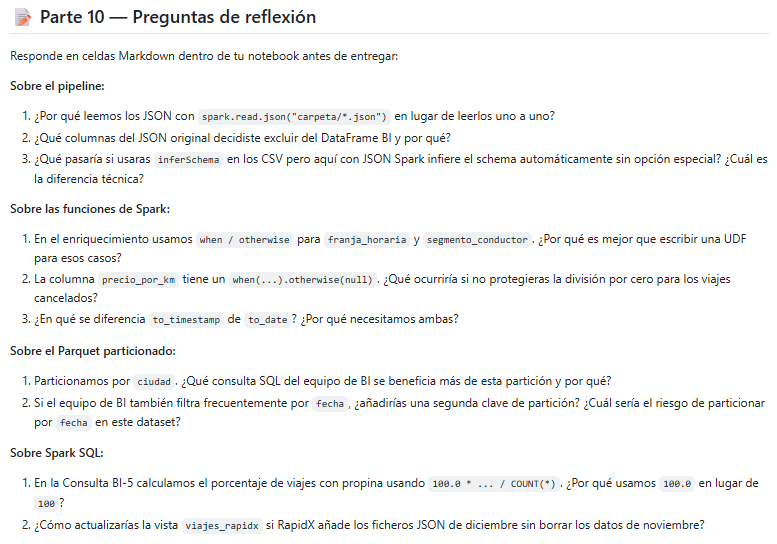

Sobre el pipeline:
¿Por qué leemos los JSON con spark.read.json("carpeta/*.json") en lugar de leerlos uno a uno?Porque Spark es un sistema distribuido diseñado para la lectura masiva. Usar el comodín * permite a Spark cargar todos los archivos en un solo DataFrame de forma paralela, simplificando el código y permitiendo que el motor de ejecución optimice la lectura de todo el conjunto de datos a la vez.

¿Qué columnas del JSON original decidiste excluir del DataFrame BI y por qué?Se excluyeron las columnas operacionales y técnicas (como id_sistema_interno, logs_servidor o metadata_api). El equipo de BI solo necesita datos limpios para análisis de negocio; las columnas con ruido técnico solo aumentan el tamaño del archivo Parquet y ralentizan las consultas sin aportar valor analítico.

¿Qué pasaría si usaras inferSchema en los CSV pero aquí con JSON Spark infiere el schema automáticamente sin opción especial? ¿Cuál es la diferencia técnica?A diferencia del CSV (que es texto plano sin estructura), el JSON es un formato semiestructurado que ya contiene información sobre tipos de datos (como llaves, comillas para strings, o números sin comillas). Spark lee la estructura intrínseca del JSON por defecto, mientras que en el CSV necesita una pasada extra (inferSchema) para intentar adivinar los tipos.

Sobre las funciones de Spark:
En el enriquecimiento usamos when / otherwise. ¿Por qué es mejor que escribir una UDF para esos casos?Es mejor por el rendimiento. Las funciones nativas de Spark (when/otherwise) se ejecutan directamente en la JVM de forma optimizada por el motor Catalyst. Una UDF (User Defined Function) obliga a Spark a serializar los datos y pausar sus optimizaciones internas, lo que hace que el proceso sea mucho más lento.

La columna precio_por_km tiene un when(...).otherwise(null). ¿Qué ocurriría si no protegieras la división por cero para los viajes cancelados?Si un viaje cancelado tiene distancia = 0, la operación matemática lanzaría un error de división por cero o devolvería valores Infinity/NaN, lo que corrompería los promedios y reportes finales del equipo de BI.

¿En qué se diferencia to_timestamp de to_date? ¿Por qué necesitamos ambas?to_timestamp guarda la fecha y la hora exacta (precisión de segundos), esencial para calcular la franja_horaria. to_date solo guarda el día/mes/año, lo cual es mucho más eficiente para agrupaciones diarias y para definir la fecha de particionado.

Sobre el Parquet particionado:

Particionamos por ciudad. ¿Qué consulta SQL del equipo de BI se beneficia más de esta partición y por qué?Cualquier consulta que incluya un filtro WHERE ciudad = 'Madrid'. Gracias a la partición, Spark aplica Partition Pruning y solo lee la carpeta física de Madrid, ignorando el resto del disco y ahorrando mucho tiempo de lectura.

Si el equipo de BI también filtra frecuentemente por fecha, ¿añadirías una segunda clave de partición? ¿Cuál sería el riesgo?Sí, se podría particionar por /ciudad/fecha/. El riesgo es el Small File Problem: si hay pocas filas por ciudad/día, terminaremos con miles de archivos diminutos en disco, lo que degrada drásticamente el rendimiento del sistema de archivos.

Sobre Spark SQL:
En la Consulta BI-5 calculamos el porcentaje usando 100.0 * ... / COUNT(*). ¿Por qué usamos 100.0 en lugar de 100?Para forzar una división de punto flotante (decimal). En Spark, si divides dos números enteros (como 100 / 7), el resultado se trunca a un entero. Al usar 100.0, aseguramos que el resultado sea un decimal preciso (ej. 14.28).

¿Cómo actualizarías la vista viajes_rapidx si RapidX añade ficheros JSON de diciembre sin borrar los datos de noviembre?Usaría el modo append al escribir el Parquet (.write.mode("append").parquet(...)) y luego volvería a ejecutar el comando createOrReplaceTempView. Esto añade los nuevos datos al Data Lake y refresca la vista SQL para que incluya ambos meses.